In [3]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python:", sys.executable)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("\n✅ IITKGP ML Hackathon environment ready!")

Python: c:\IITKGP_Fugacity_ML\.venv\Scripts\python.exe
Pandas: 3.0.5
NumPy: 2.5.1

✅ IITKGP ML Hackathon environment ready!


In [4]:
from pathlib import Path

DATA = Path("../data/raw")

train = pd.read_csv(DATA / "train_dataset.csv")
test = pd.read_csv(DATA / "test_dataset.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train shape: (150, 6)
Test shape: (50, 5)

Train columns:
['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K', 'length_m', 'jacket_temperature_K', 'overall_yield']

Test columns:
['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K', 'length_m', 'jacket_temperature_K']


# Dataset Overview

In [5]:
# First 5 rows
display(train.head())

# Last 5 rows
display(train.tail())

# First 5 rows of test
display(test.head())

# Last 5 rows of test
display(test.tail())

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
0,33.09,3.68,357.75,19.87,383.79,63.024
1,76.30,1.34,429.70,14.84,405.72,86.611
2,59.90,1.01,431.10,11.76,385.40,86.347
3,49.90,2.21,445.61,22.85,367.74,92.175
4,16.70,3.95,458.91,4.56,374.13,82.211


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
145,7.77,2.33,492.09,12.90,529.91,0.000
146,50.72,3.19,497.90,17.35,426.78,1.249
147,42.70,1.26,463.01,5.96,458.71,0.645
148,8.86,2.68,406.44,6.42,531.29,0.000
149,25.90,0.80,362.53,2.94,474.85,28.516


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K
0,43.73,2.88,454.18,7.66,440.61
1,47.80,2.33,401.37,19.95,390.13
2,7.14,0.65,411.86,3.05,476.23
3,17.86,1.28,385.97,22.36,353.56
4,56.40,2.51,495.33,8.36,517.71


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K
45,25.67,3.45,389.93,20.55,401.11
46,55.44,1.85,486.49,5.00,396.54
47,17.32,2.43,436.94,18.80,502.22
48,57.60,2.99,403.95,2.13,538.69
49,41.57,2.86,477.90,16.97,445.56


## Observations

- Training dataset contains 150 rows.
- Test dataset contains 50 rows.
- All predictor columns are numerical.
- Target column (overall_yield) exists only in the training dataset.
- Feature names match between train and test datasets.


# Data Types

In [6]:
train.info()

print("\n")

test.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   flow_rate_L_min       150 non-null    float64
 1   concentration_mol_L   150 non-null    float64
 2   inlet_temperature_K   150 non-null    float64
 3   length_m              150 non-null    float64
 4   jacket_temperature_K  150 non-null    float64
 5   overall_yield         150 non-null    float64
dtypes: float64(6)
memory usage: 7.2 KB


<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   flow_rate_L_min       50 non-null     float64
 1   concentration_mol_L   50 non-null     float64
 2   inlet_temperature_K   50 non-null     float64
 3   length_m              50 non-null     float64
 4   jacket_temperature_K  50 non-null     float64
dtypes: f

## Observations

All variables are numeric.

No categorical encoding is required.

The dataset is already suitable for regression algorithms.

In [7]:
print("Training memory usage")

train.memory_usage(deep=True)

print("\nTotal")

print(train.memory_usage(deep=True).sum()/1024, "KB")

Training memory usage

Total
7.16015625 KB


# Summary Statistics


In [6]:
display(train.describe().T)

,count,mean,std,min,25%,50%,75%,max
flow_rate_L_min,150.0,40.466800,22.239772,5.41,21.1125,38.610,61.2275,79.020
concentration_mol_L,150.0,2.311333,1.019844,0.52,1.3625,2.445,3.1550,3.970
inlet_temperature_K,150.0,424.423400,45.200641,351.63,387.2550,425.630,462.9725,498.580
length_m,150.0,14.086533,6.995343,2.26,8.0275,14.235,20.6850,24.990
jacket_temperature_K,150.0,442.240800,55.047768,354.01,393.3275,437.080,486.1800,547.990
overall_yield,150.0,36.222173,38.427427,0.00,0.0135,15.314,74.8765,99.971


In [5]:
display(
    train.describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    ).T
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
flow_rate_L_min,150.0,40.466800,22.239772,5.41,6.0198,8.4305,21.1125,38.610,61.2275,75.9675,77.81140,79.020
concentration_mol_L,150.0,2.311333,1.019844,0.52,0.5398,0.6345,1.3625,2.445,3.1550,3.7800,3.93040,3.970
inlet_temperature_K,150.0,424.423400,45.200641,351.63,352.4393,356.8450,387.2550,425.630,462.9725,492.5540,497.95100,498.580
length_m,150.0,14.086533,6.995343,2.26,2.3045,3.0445,8.0275,14.235,20.6850,24.3100,24.88080,24.990
jacket_temperature_K,150.0,442.240800,55.047768,354.01,357.5948,366.1850,393.3275,437.080,486.1800,535.1105,546.89820,547.990
overall_yield,150.0,36.222173,38.427427,0.00,0.0000,0.0000,0.0135,15.314,74.8765,96.7090,99.82373,99.971


In [10]:
train.nunique()

flow_rate_L_min         149
concentration_mol_L     121
inlet_temperature_K     150
length_m                145
jacket_temperature_K    149
overall_yield           114
dtype: int64

# Missing Values

In [11]:
train.isnull().sum()

flow_rate_L_min         0
concentration_mol_L     0
inlet_temperature_K     0
length_m                0
jacket_temperature_K    0
overall_yield           0
dtype: int64

In [12]:
test.isnull().sum()

flow_rate_L_min         0
concentration_mol_L     0
inlet_temperature_K     0
length_m                0
jacket_temperature_K    0
dtype: int64

No missing values detected.

No imputation is required.

In [13]:
print(train.duplicated().sum())

print(test.duplicated().sum())

0
0


In [14]:
train.T.duplicated().sum()

np.int64(0)

In [15]:
constant = [
    c
    for c in train.columns
    if train[c].nunique()==1
]

constant

[]

In [16]:
near_constant = []

for col in train.columns:

    freq = train[col].value_counts(normalize=True).iloc[0]

    if freq > 0.95:

        near_constant.append(col)

near_constant

[]

In [17]:
import numpy as np

np.isinf(train).sum()


flow_rate_L_min         0
concentration_mol_L     0
inlet_temperature_K     0
length_m                0
jacket_temperature_K    0
overall_yield           0
dtype: int64

# Data Understanding Summary

### Dataset

- Training observations: 150
- Testing observations: 50
- Predictor variables: 5
- Target variable: `overall_yield`

### Data Quality

- No missing values
- No duplicate rows
- No duplicate columns
- No constant features
- No near-constant features
- No invalid numerical values

### Initial Findings

- All predictor variables are continuous numerical measurements.
- The dataset is clean and requires minimal preprocessing before modeling.
- Predictor variables span broad operating ranges, suggesting that the experiments explore diverse reactor conditions.
- The target variable ranges from approximately 0 to 100 and appears to have a non-symmetric distribution based on the difference between its mean and median.
- A detailed target distribution analysis is required before selecting modeling techniques.

# Target Variable Analysis

The objective of this section is to understand the statistical
properties and distribution of the target variable (`overall_yield`).

Understanding the target helps in selecting suitable machine learning
models and identifying potential challenges related to RMSE.

In [18]:
target = train["overall_yield"]

print("Mean       :", target.mean())
print("Median     :", target.median())
print("Variance   :", target.var())
print("Std Dev    :", target.std())
print("Minimum    :", target.min())
print("Maximum    :", target.max())
print("Skewness   :", target.skew())
print("Kurtosis   :", target.kurt())

Mean       : 36.22217333333333
Median     : 15.314
Variance   : 1476.6671488959284
Std Dev    : 38.42742703975805
Minimum    : 0.0
Maximum    : 99.971
Skewness   : 0.4217809099274811
Kurtosis   : -1.5386795611946784


## Histogram of Target Variable

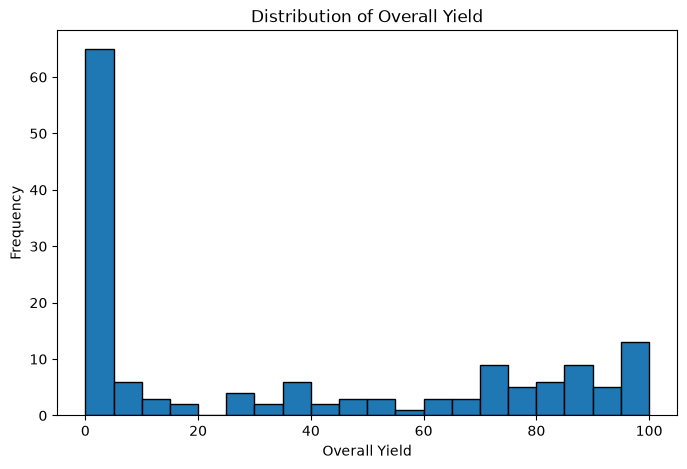

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    target,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Overall Yield")

plt.ylabel("Frequency")

plt.title("Distribution of Overall Yield")

plt.show()

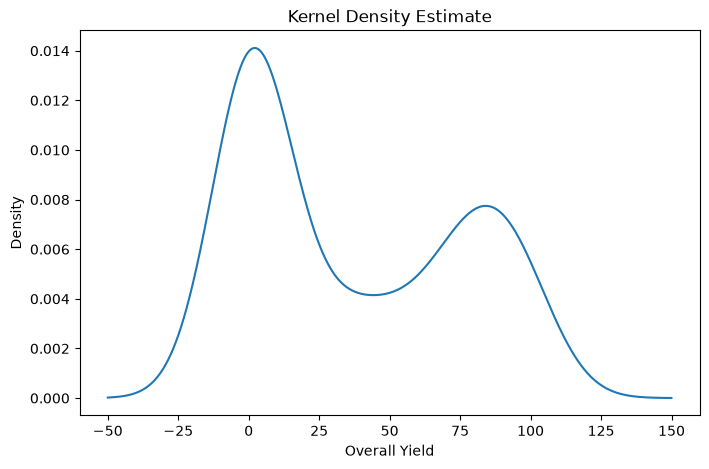

In [20]:
plt.figure(figsize=(8,5))

target.plot(
    kind="kde"
)

plt.title("Kernel Density Estimate")

plt.xlabel("Overall Yield")

plt.show()

C:\Users\chaat\AppData\Local\Temp\ipykernel_25580\2943925775.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


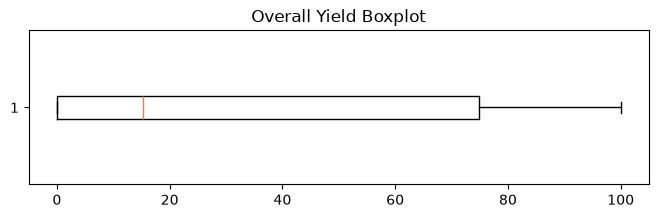

In [21]:
plt.figure(figsize=(8,2))

plt.boxplot(
    target,
    vert=False
)

plt.title("Overall Yield Boxplot")

plt.show()

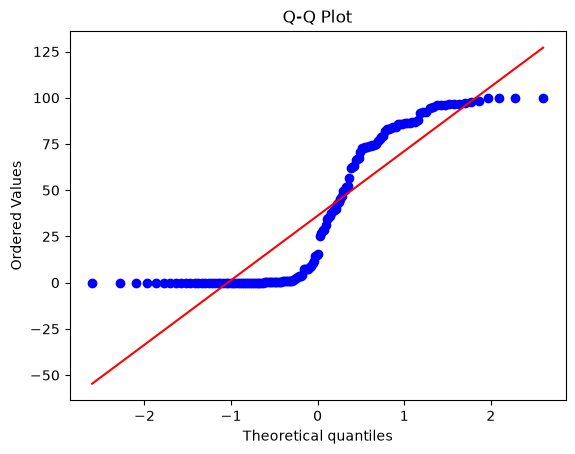

In [22]:
from scipy import stats

stats.probplot(
    target,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot")

plt.show()

In [23]:
target.quantile(
    [
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
)

0.01     0.00000
0.05     0.00000
0.25     0.01350
0.50    15.31400
0.75    74.87650
0.95    96.70900
0.99    99.82373
Name: overall_yield, dtype: float64

## Interpretation

The target variable spans almost the complete interval from 0 to 100.

The difference between the mean and median suggests that the distribution
is not perfectly symmetric.

The histogram and KDE will be used to determine whether the distribution
is skewed or multi-modal.

The boxplot helps identify extreme observations that could strongly
influence RMSE.

Since RMSE penalizes large prediction errors, understanding the tails of
the distribution is important before selecting and tuning regression
models.

## Machine Learning Implications

- RMSE will penalize large prediction errors.
- If the distribution contains extreme values, the model must predict
  them accurately.
- Target transformation will not be performed unless repeated
  cross-validation demonstrates a consistent improvement.
- Model evaluation decisions will be based on validation performance
  rather than assumptions about the target distribution.

# Feature Analysis

In this section every predictor variable is analyzed individually.

For every feature we study:

- Distribution
- Summary statistics
- Skewness
- Possible outliers
- Engineering interpretation
- Potential usefulness for prediction

# Feature 1 : Flow Rate (L/min)

In [5]:
feature = "flow_rate_L_min"

train[feature].describe()

count    150.000000
mean      40.466800
std       22.239772
min        5.410000
25%       21.112500
50%       38.610000
75%       61.227500
max       79.020000
Name: flow_rate_L_min, dtype: float64

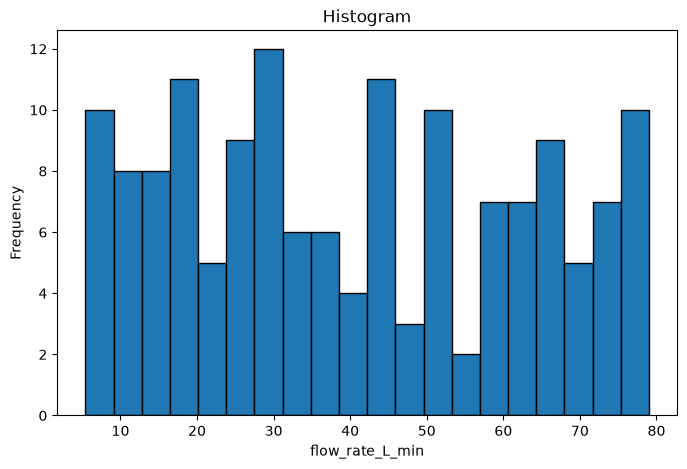

In [6]:
plt.figure(figsize=(8,5))

plt.hist(
    train[feature],
    bins=20,
    edgecolor="black"
)

plt.xlabel(feature)

plt.ylabel("Frequency")

plt.title("Histogram")

plt.show()

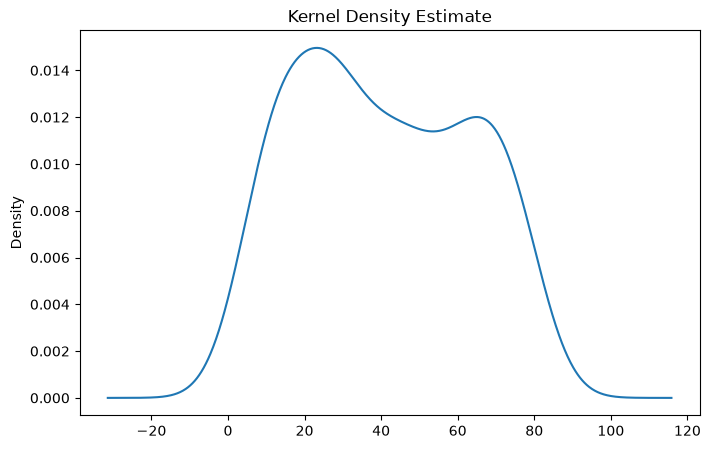

In [7]:
plt.figure(figsize=(8,5))

train[feature].plot(kind="kde")

plt.title("Kernel Density Estimate")

plt.show()

C:\Users\chaat\AppData\Local\Temp\ipykernel_13160\30990883.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


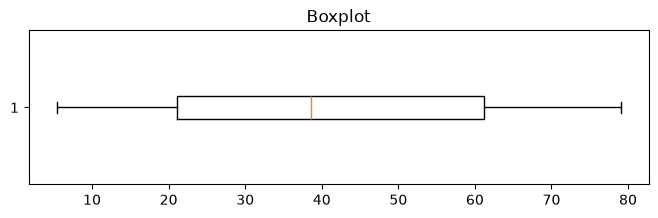

In [8]:
plt.figure(figsize=(8,2))

plt.boxplot(
    train[feature],
    vert=False
)

plt.title("Boxplot")

plt.show()

In [9]:
train[feature].quantile(
[
0.01,
0.05,
0.25,
0.50,
0.75,
0.95,
0.99
]
)

0.01     6.0198
0.05     8.4305
0.25    21.1125
0.50    38.6100
0.75    61.2275
0.95    75.9675
0.99    77.8114
Name: flow_rate_L_min, dtype: float64

## Interpretation

### Statistical Observations

- Flow rate ranges from **5.41 L/min** to **79.02 L/min**, indicating that the experiments cover a broad operating range.
- The mean flow rate is **40.47 L/min**, while the median is **38.61 L/min**.
- Since the mean and median are relatively close, the distribution does not appear to be strongly skewed.
- The standard deviation (**22.24 L/min**) indicates substantial variability across experiments.

### Distribution Analysis

- The histogram shows that flow rate values are spread across the full operating range without any severe concentration at a single value.
- The KDE plot suggests a mildly irregular distribution with slight multiple peaks, indicating that experiments were conducted under several operating conditions rather than following a perfectly normal distribution.
- The boxplot does not reveal any obvious extreme outliers.
- The percentile analysis confirms that the feature covers a wide range of operating conditions.

### Engineering Interpretation

Flow rate directly influences the residence time of reactants inside the reactor.

- Lower flow rates generally increase residence time, allowing reactants more time to convert into products.
- Higher flow rates reduce residence time, which may decrease conversion if the reaction is kinetically limited.

Therefore, flow rate is expected to have a meaningful influence on overall reactor yield.

### Machine Learning Implications

- No immediate preprocessing is required for this feature.
- No evidence suggests removing observations based on flow rate.
- Flow rate should be retained as an important predictor for model training.
- Later in the project, interaction features involving flow rate (for example, with reactor length or concentration) may improve predictive performance.

In [10]:
feature = "concentration_mol_L"

train[feature].describe()

count    150.000000
mean       2.311333
std        1.019844
min        0.520000
25%        1.362500
50%        2.445000
75%        3.155000
max        3.970000
Name: concentration_mol_L, dtype: float64

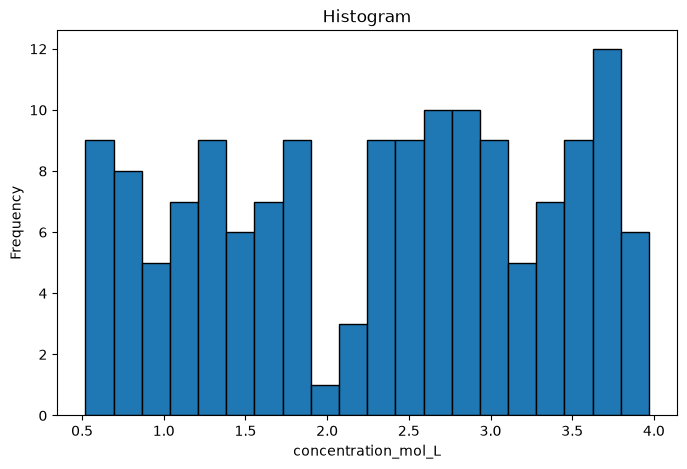

In [11]:
plt.figure(figsize=(8,5))

plt.hist(
    train[feature],
    bins=20,
    edgecolor="black"
)

plt.xlabel(feature)

plt.ylabel("Frequency")

plt.title("Histogram")

plt.show()

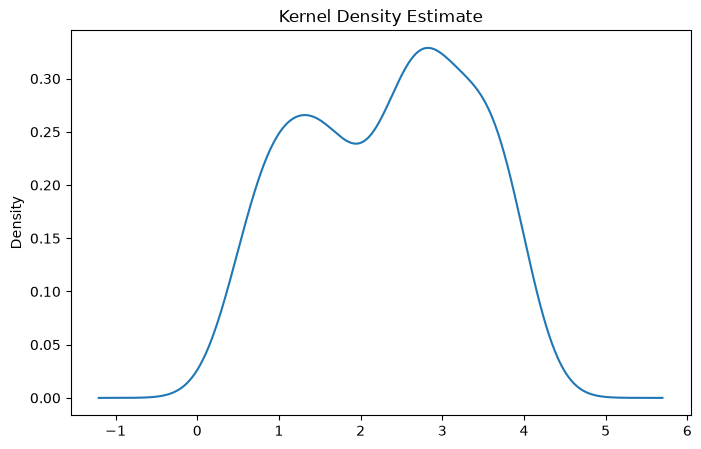

In [12]:
plt.figure(figsize=(8,5))

train[feature].plot(kind="kde")

plt.title("Kernel Density Estimate")

plt.show()

C:\Users\chaat\AppData\Local\Temp\ipykernel_13160\30990883.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


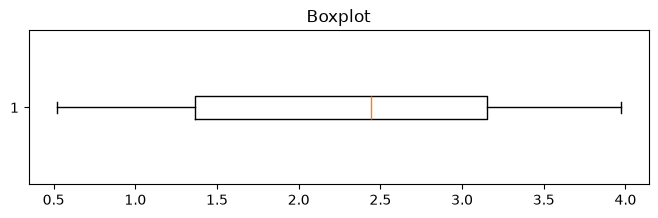

In [13]:
plt.figure(figsize=(8,2))

plt.boxplot(
    train[feature],
    vert=False
)

plt.title("Boxplot")

plt.show()

In [14]:
train[feature].quantile(
[
0.01,
0.05,
0.25,
0.50,
0.75,
0.95,
0.99
]
)

0.01    0.5398
0.05    0.6345
0.25    1.3625
0.50    2.4450
0.75    3.1550
0.95    3.7800
0.99    3.9304
Name: concentration_mol_L, dtype: float64

## Interpretation

### Statistical Observations

- Reactant concentration ranges from **0.52 mol/L** to **3.97 mol/L**, covering a broad concentration range.
- The mean concentration is **2.31 mol/L**, while the median is **2.45 mol/L**.
- Since the mean and median are very close, the distribution appears approximately balanced with only slight asymmetry.
- The standard deviation (**1.02 mol/L**) indicates good variability across experimental conditions.

### Distribution Analysis

- The histogram shows that concentration values are reasonably well distributed across the operating range.
- The KDE plot suggests a slightly multi-modal distribution, indicating that experiments were likely performed under multiple concentration settings rather than a single continuous operating regime.
- The boxplot does not reveal any obvious extreme outliers.
- Percentile analysis confirms that observations are spread throughout the concentration range without excessive clustering.

### Engineering Interpretation

Reactant concentration is one of the most fundamental variables controlling chemical reaction performance.

- Increasing concentration generally increases the probability of molecular collisions, which may increase the reaction rate depending on the reaction kinetics.
- Extremely low concentrations may reduce product formation due to insufficient reactant availability.
- Higher concentrations may improve conversion until other process limitations become dominant.

Therefore, concentration is expected to be an important predictor of overall reactor yield.

### Machine Learning Implications

- No preprocessing is required for this feature.
- No suspicious or impossible concentration values are observed.
- The feature should be retained for model training.
- Later in the project, interaction features involving concentration (such as concentration × temperature or concentration × flow rate) may improve predictive performance.

In [15]:
feature = "inlet_temperature_K"

train[feature].describe()

count    150.000000
mean     424.423400
std       45.200641
min      351.630000
25%      387.255000
50%      425.630000
75%      462.972500
max      498.580000
Name: inlet_temperature_K, dtype: float64

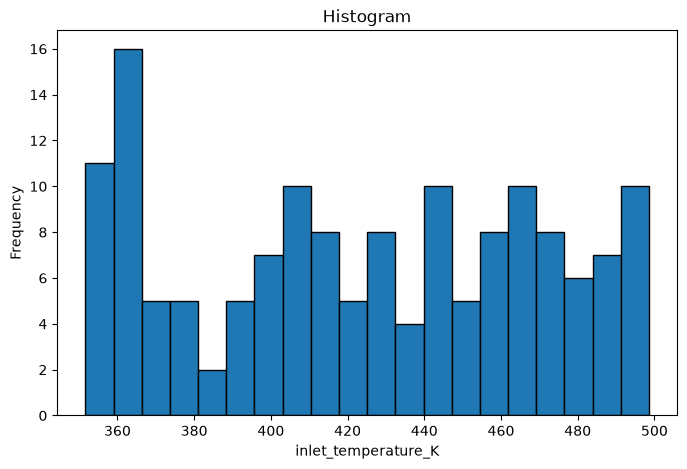

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    train[feature],
    bins=20,
    edgecolor="black"
)

plt.xlabel(feature)

plt.ylabel("Frequency")

plt.title("Histogram")

plt.show()

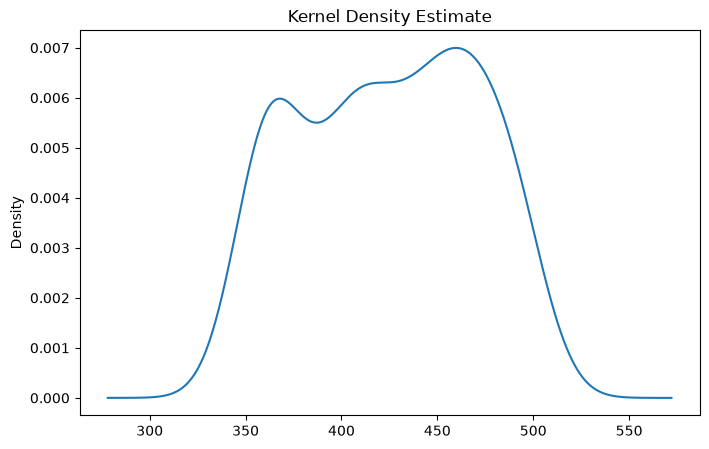

In [17]:
plt.figure(figsize=(8,5))

train[feature].plot(kind="kde")

plt.title("Kernel Density Estimate")

plt.show()

C:\Users\chaat\AppData\Local\Temp\ipykernel_13160\30990883.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


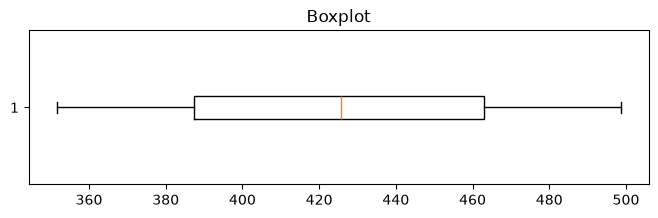

In [18]:
plt.figure(figsize=(8,2))

plt.boxplot(
    train[feature],
    vert=False
)

plt.title("Boxplot")

plt.show()

In [19]:
train[feature].quantile(
[
0.01,
0.05,
0.25,
0.50,
0.75,
0.95,
0.99
]
)

0.01    352.4393
0.05    356.8450
0.25    387.2550
0.50    425.6300
0.75    462.9725
0.95    492.5540
0.99    497.9510
Name: inlet_temperature_K, dtype: float64

## Interpretation

### Statistical Observations

- The inlet temperature ranges from **351.63 K** to **498.58 K**, indicating that the experiments cover a broad thermal operating window.
- The mean inlet temperature is **424.42 K**, while the median is **425.63 K**.
- Since the mean and median are nearly identical, the distribution is approximately symmetric with little evidence of strong skewness.
- The standard deviation (**45.20 K**) indicates substantial variation in operating temperatures across experiments.

### Distribution Analysis

- The histogram shows that inlet temperatures are distributed across the full operating range rather than being concentrated around a single value.
- The KDE plot suggests multiple local peaks, indicating that experiments were likely conducted at several temperature settings instead of a single continuous operating condition.
- The boxplot does not indicate any obvious extreme outliers.
- Percentile analysis confirms that temperatures span a wide range, from approximately **352 K (1st percentile)** to **498 K (99th percentile)**.

### Engineering Interpretation

Inlet temperature is one of the most important operating variables in a chemical reactor.

- Temperature directly affects reaction kinetics according to the Arrhenius equation.
- Increasing temperature generally increases reaction rates, although excessively high temperatures may promote undesirable side reactions or reduce selectivity depending on the reaction system.
- Because temperature strongly influences reaction kinetics, inlet temperature is expected to be a major factor affecting overall reactor yield.

### Machine Learning Implications

- No preprocessing is currently required for this feature.
- No suspicious or physically unrealistic temperature values are observed in the dataset.
- This feature should be retained for all machine learning models.
- Later feature engineering should consider interaction terms involving inlet temperature, particularly with jacket temperature, concentration, and flow rate, as these interactions may better represent reactor behavior.

In [20]:
feature = "length_m"

train[feature].describe()

count    150.000000
mean      14.086533
std        6.995343
min        2.260000
25%        8.027500
50%       14.235000
75%       20.685000
max       24.990000
Name: length_m, dtype: float64

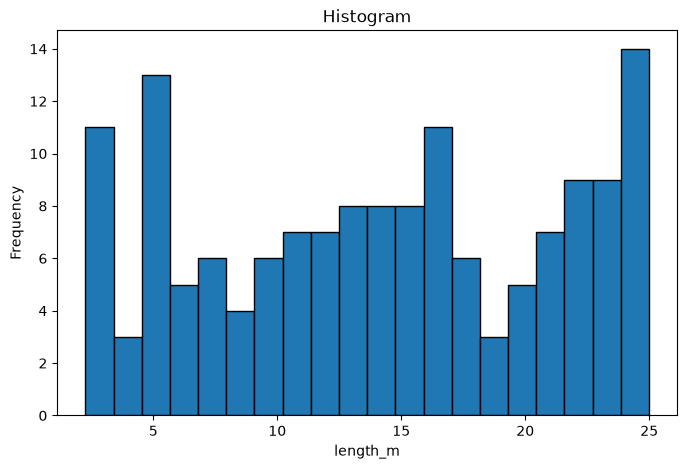

In [21]:
plt.figure(figsize=(8,5))

plt.hist(
    train[feature],
    bins=20,
    edgecolor="black"
)

plt.xlabel(feature)

plt.ylabel("Frequency")

plt.title("Histogram")

plt.show()

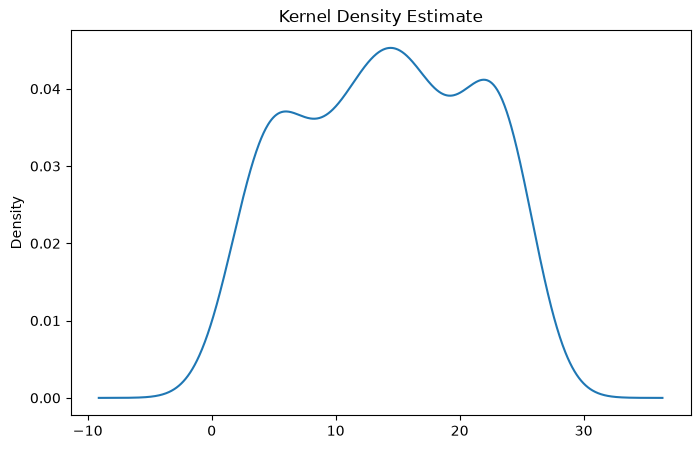

In [22]:
plt.figure(figsize=(8,5))

train[feature].plot(kind="kde")

plt.title("Kernel Density Estimate")

plt.show()

C:\Users\chaat\AppData\Local\Temp\ipykernel_13160\30990883.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


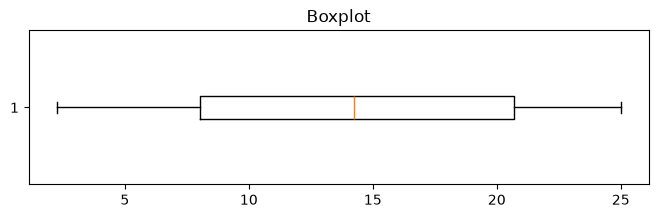

In [23]:
plt.figure(figsize=(8,2))

plt.boxplot(
    train[feature],
    vert=False
)

plt.title("Boxplot")

plt.show()

In [24]:
train[feature].quantile(
[
0.01,
0.05,
0.25,
0.50,
0.75,
0.95,
0.99
]
)

0.01     2.3045
0.05     3.0445
0.25     8.0275
0.50    14.2350
0.75    20.6850
0.95    24.3100
0.99    24.8808
Name: length_m, dtype: float64

## Interpretation

### Statistical Observations

- Reactor length ranges from **2.26 m** to **24.99 m**, indicating that experiments were conducted across a wide range of reactor sizes.
- The mean reactor length is **14.09 m**, while the median is **14.24 m**.
- Since the mean and median are nearly identical, the distribution is approximately symmetric with no strong evidence of skewness.
- The standard deviation (**7.00 m**) indicates considerable variation in reactor length across experiments.

### Distribution Analysis

- The histogram shows that reactor lengths are distributed throughout the operating range without excessive concentration in any single region.
- The KDE plot exhibits multiple gentle peaks, suggesting that experiments may have been performed at several preferred reactor lengths rather than at completely random values.
- The boxplot does not indicate any obvious extreme outliers.
- Percentile analysis confirms that reactor lengths span almost the entire operating range, from approximately **2.30 m (1st percentile)** to **24.88 m (99th percentile)**.

### Engineering Interpretation

Reactor length directly influences the residence time of reactants within the reactor.

- A longer reactor generally provides reactants with more time to react, potentially increasing conversion and product yield.
- However, the relationship may not be strictly linear because reaction kinetics, heat transfer, and mass transfer effects can also influence performance.
- Reactor length is therefore expected to interact with flow rate, since residence time depends on both variables.

### Machine Learning Implications

- No preprocessing is required for this feature.
- No suspicious or unrealistic reactor length values are observed.
- Reactor length should be retained as an important predictor.
- Feature engineering involving **flow rate × reactor length** or a **residence-time proxy** may improve predictive performance in later stages.

In [28]:
feature = "jacket_temperature_K"

train[feature].describe()

count    150.000000
mean     442.240800
std       55.047768
min      354.010000
25%      393.327500
50%      437.080000
75%      486.180000
max      547.990000
Name: jacket_temperature_K, dtype: float64

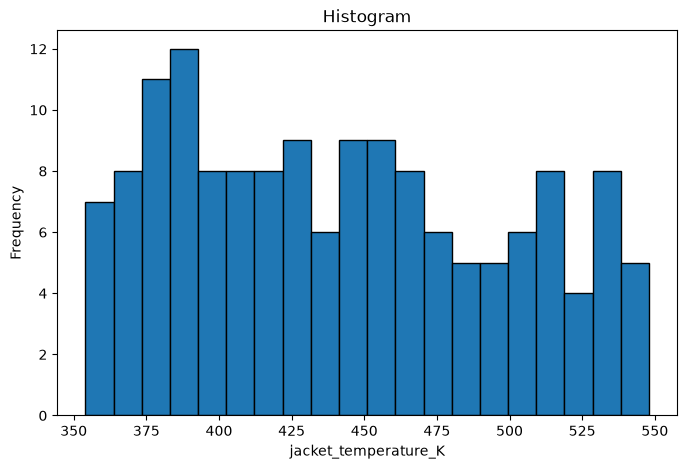

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    train[feature],
    bins=20,
    edgecolor="black"
)

plt.xlabel(feature)

plt.ylabel("Frequency")

plt.title("Histogram")

plt.show()

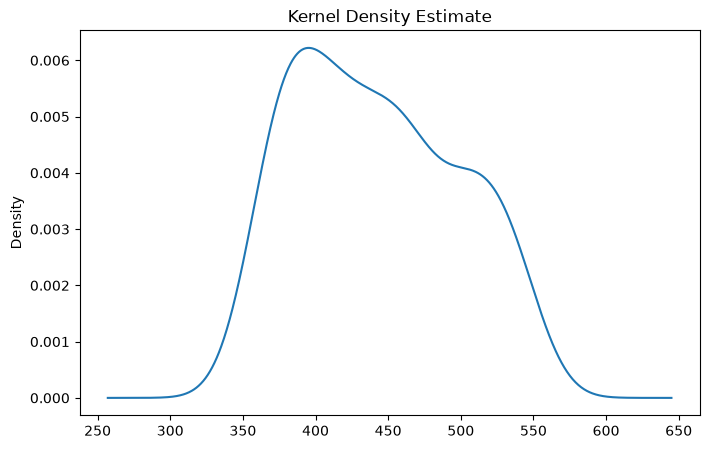

In [30]:
plt.figure(figsize=(8,5))

train[feature].plot(kind="kde")

plt.title("Kernel Density Estimate")

plt.show()

C:\Users\chaat\AppData\Local\Temp\ipykernel_13160\30990883.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


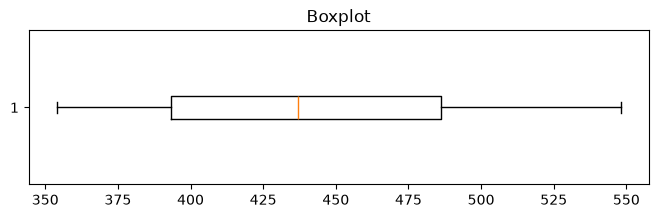

In [31]:
plt.figure(figsize=(8,2))

plt.boxplot(
    train[feature],
    vert=False
)

plt.title("Boxplot")

plt.show()

In [32]:
train[feature].quantile(
[
0.01,
0.05,
0.25,
0.50,
0.75,
0.95,
0.99
]
)

0.01    357.5948
0.05    366.1850
0.25    393.3275
0.50    437.0800
0.75    486.1800
0.95    535.1105
0.99    546.8982
Name: jacket_temperature_K, dtype: float64

## Interpretation

### Statistical Observations

- Jacket temperature ranges from **354.01 K** to **547.99 K**, covering a wide thermal operating range.
- The mean jacket temperature is **442.24 K**, while the median is **437.08 K**.
- The mean and median are relatively close, indicating that the distribution is reasonably balanced with only slight asymmetry.
- The standard deviation (**55.05 K**) indicates substantial variation in jacket temperatures across experiments.

### Distribution Analysis

- The histogram shows that jacket temperatures are distributed across a broad operating range rather than being concentrated around a single value.
- The KDE plot suggests multiple local peaks, indicating that experiments were likely conducted under several controlled jacket temperature settings.
- The boxplot does not reveal any obvious extreme outliers.
- Percentile analysis confirms that observations cover almost the complete operating range, from approximately **358 K (1st percentile)** to **547 K (99th percentile)**.

### Engineering Interpretation

Jacket temperature controls the rate of heat transfer between the reactor and its surroundings.

- Proper heat transfer is essential for maintaining the desired reaction temperature.
- A higher jacket temperature may increase reaction rates by supplying heat, while a lower jacket temperature may reduce reaction rates or improve selectivity depending on the reaction.
- The influence of jacket temperature is expected to depend strongly on inlet temperature rather than acting independently.

### Machine Learning Implications

- No preprocessing is required for this feature.
- No suspicious or unrealistic values are observed.
- Jacket temperature should be retained for all machine learning models.
- Feature engineering involving **temperature difference** (`jacket_temperature_K - inlet_temperature_K`) and **temperature ratio** may improve predictive performance by better representing reactor heat transfer behavior.

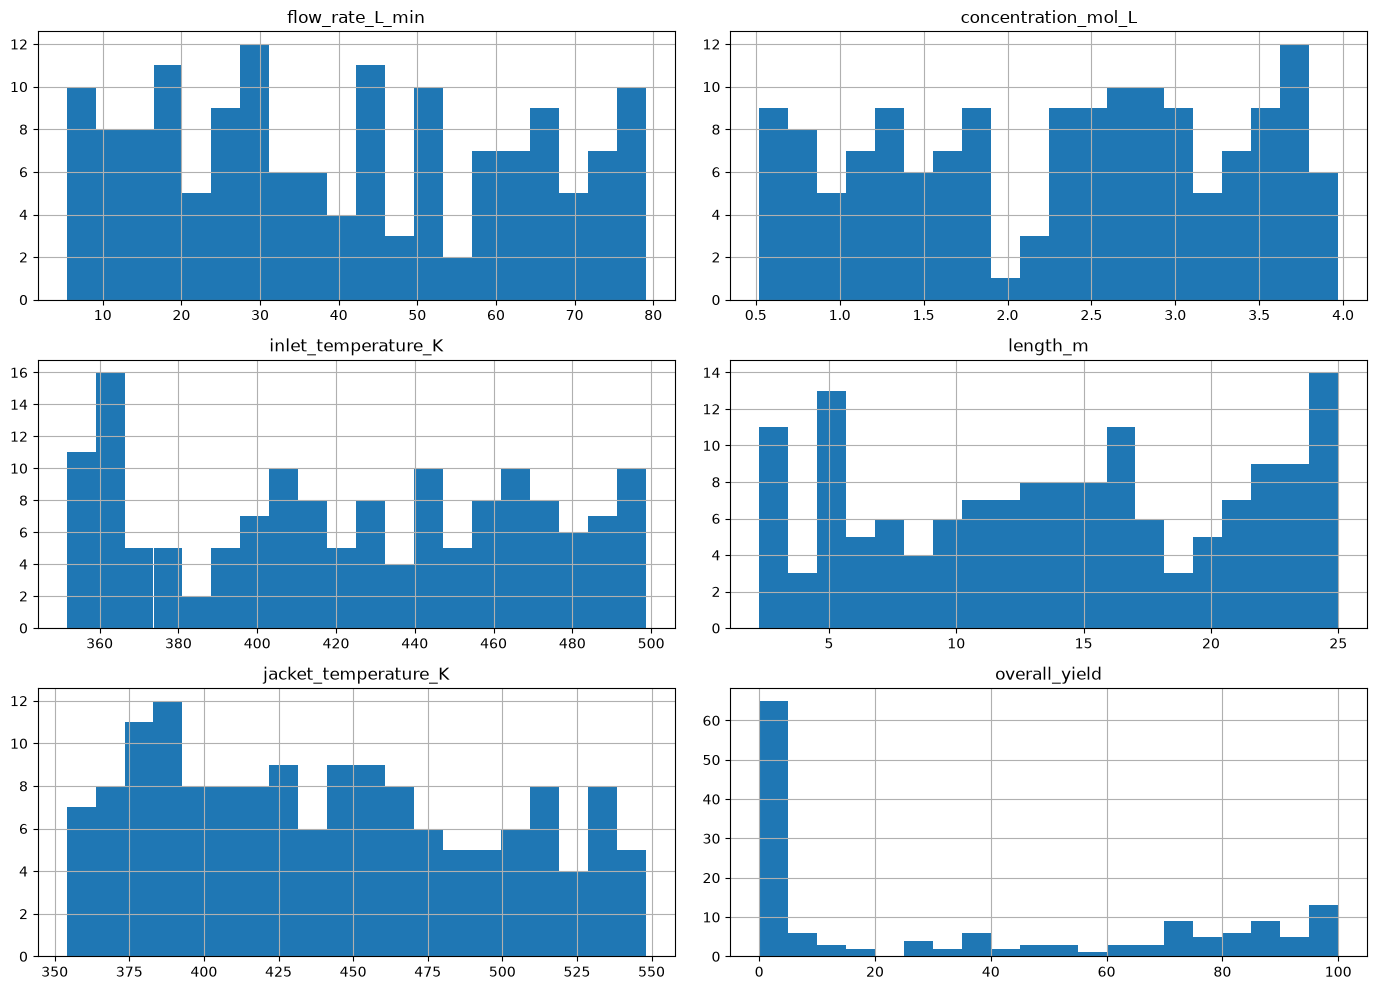

In [33]:
train.hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()

plt.show()

# Feature Analysis Summary

## Flow Rate (flow_rate_L_min)

### Observation
- Flow rate ranges from **5.41 L/min** to **79.02 L/min**.
- The distribution covers a broad operating range with no obvious outliers.
- Mean and median are close, indicating only slight skewness.

### Engineering Interpretation
Flow rate influences the residence time of reactants inside the reactor. Lower flow rates generally increase residence time, while higher flow rates reduce reaction time available for conversion.

### Potential Usefulness
High

Possible future engineered features:
- Flow Rate × Reactor Length
- Reactor Length / Flow Rate (Residence Time Proxy)

---

## Concentration (concentration_mol_L)

### Observation
- Concentration ranges from **0.52** to **3.97 mol/L**.
- Values are well distributed with no suspicious observations.
- No significant outliers are visible.

### Engineering Interpretation
Reactant concentration directly influences molecular collision frequency and reaction rate. Higher concentrations may improve conversion depending on reaction kinetics.

### Potential Usefulness
High

Possible future engineered features:
- Concentration × Temperature
- Concentration × Flow Rate

---

## Inlet Temperature (inlet_temperature_K)

### Observation
- Temperature spans approximately **352 K to 499 K**.
- Broad operating window.
- No obvious outliers.

### Engineering Interpretation
Temperature strongly affects reaction kinetics according to the Arrhenius equation. It is expected to be one of the most influential variables affecting yield.

### Potential Usefulness
Very High

Possible future engineered features:
- Inlet Temperature²
- Inlet Temperature × Concentration
- Inlet Temperature × Jacket Temperature

---

## Reactor Length (length_m)

### Observation
- Reactor length ranges from **2.26 m** to **24.99 m**.
- Distribution is reasonably balanced.
- No suspicious values.

### Engineering Interpretation
Longer reactors generally increase residence time, potentially increasing conversion. The relationship is expected to depend strongly on flow rate.

### Potential Usefulness
High

Possible future engineered features:
- Length × Flow Rate
- Length / Flow Rate

---

## Jacket Temperature (jacket_temperature_K)

### Observation
- Jacket temperature ranges from **354 K** to **548 K**.
- Broad distribution with no obvious outliers.
- Multiple operating temperature regions appear to exist.

### Engineering Interpretation
Jacket temperature controls heat transfer into or out of the reactor. Its effect is expected to interact with inlet temperature rather than acting independently.

### Potential Usefulness
Very High

Possible future engineered features:
- Jacket − Inlet Temperature
- Jacket / Inlet Temperature
- Jacket × Concentration

---

# Overall Feature Assessment

## Dataset Quality

- No missing values
- No duplicate rows
- No duplicate columns
- No constant features
- No near-constant features
- No obvious outliers
- No invalid numerical values

## Initial Engineering Insights

The dataset represents experiments conducted across a wide range of reactor operating conditions. All predictor variables exhibit sufficient variability to contribute meaningful information during model training.

Based on domain knowledge, **temperature-related variables, flow rate, and concentration are expected to play major roles in determining reactor yield**. Interactions between these variables are likely to provide additional predictive power and will be explored during feature engineering.

# Correlation Analysis

The objective of this section is to understand the relationships between
all variables and identify predictors that are most strongly associated
with the target variable (`overall_yield`).

Both Pearson and Spearman correlation coefficients are analyzed.

In [34]:
pearson_corr = train.corr(method="pearson")

display(pearson_corr)

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
flow_rate_L_min,1.000000,0.035355,-0.136415,-0.022232,-0.040331,0.038070
concentration_mol_L,0.035355,1.000000,-0.036780,-0.074622,0.058447,0.008673
inlet_temperature_K,-0.136415,-0.036780,1.000000,0.009654,0.017809,-0.405145
length_m,-0.022232,-0.074622,0.009654,1.000000,-0.022217,0.079985
jacket_temperature_K,-0.040331,0.058447,0.017809,-0.022217,1.000000,-0.498384
overall_yield,0.038070,0.008673,-0.405145,0.079985,-0.498384,1.000000


### Pearson Correlation

Pearson correlation measures the strength of a **linear relationship**
between two continuous variables.

Values range from:

- +1 → Strong positive relationship
- 0 → No linear relationship
- -1 → Strong negative relationship

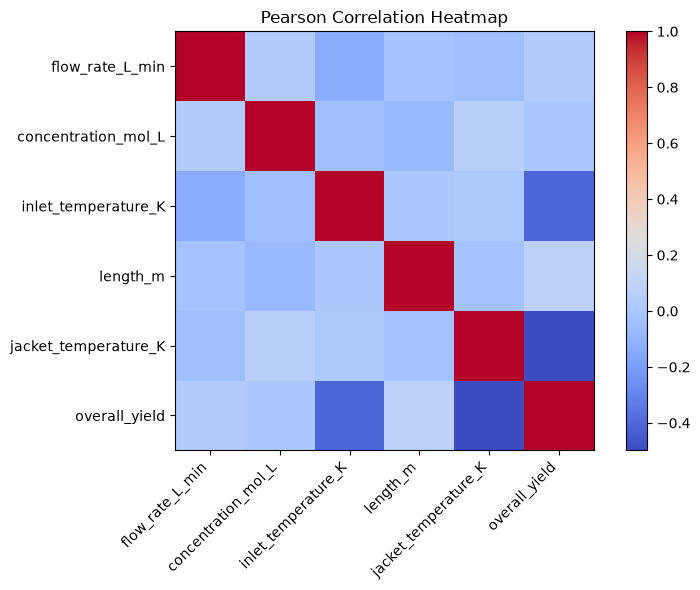

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(
    pearson_corr,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(pearson_corr.columns)),
    pearson_corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(pearson_corr.columns)),
    pearson_corr.columns
)

plt.title("Pearson Correlation Heatmap")

plt.tight_layout()

plt.show()

In [36]:
spearman_corr = train.corr(method="spearman")

display(spearman_corr)

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
flow_rate_L_min,1.000000,0.029563,-0.136886,-0.016891,-0.034787,0.111418
concentration_mol_L,0.029563,1.000000,-0.039263,-0.082640,0.046780,0.039853
inlet_temperature_K,-0.136886,-0.039263,1.000000,0.009945,0.001780,-0.377749
length_m,-0.016891,-0.082640,0.009945,1.000000,-0.029881,0.013066
jacket_temperature_K,-0.034787,0.046780,0.001780,-0.029881,1.000000,-0.594847
overall_yield,0.111418,0.039853,-0.377749,0.013066,-0.594847,1.000000


### Spearman Correlation

Spearman correlation measures the strength of a **monotonic**
relationship between variables.

Unlike Pearson correlation, it is less sensitive to non-linear
relationships and outliers.

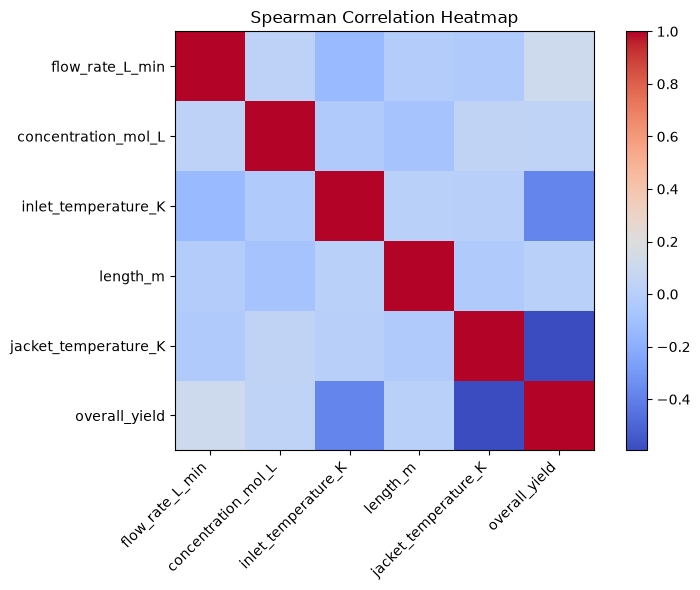

In [37]:
plt.figure(figsize=(8,6))

plt.imshow(
    spearman_corr,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(spearman_corr.columns)),
    spearman_corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(spearman_corr.columns)),
    spearman_corr.columns
)

plt.title("Spearman Correlation Heatmap")

plt.tight_layout()

plt.show()

In [38]:
target_corr = (
    pearson_corr["overall_yield"]
    .drop("overall_yield")
    .sort_values(ascending=False)
)

target_corr

length_m                0.079985
flow_rate_L_min         0.038070
concentration_mol_L     0.008673
inlet_temperature_K    -0.405145
jacket_temperature_K   -0.498384
Name: overall_yield, dtype: float64

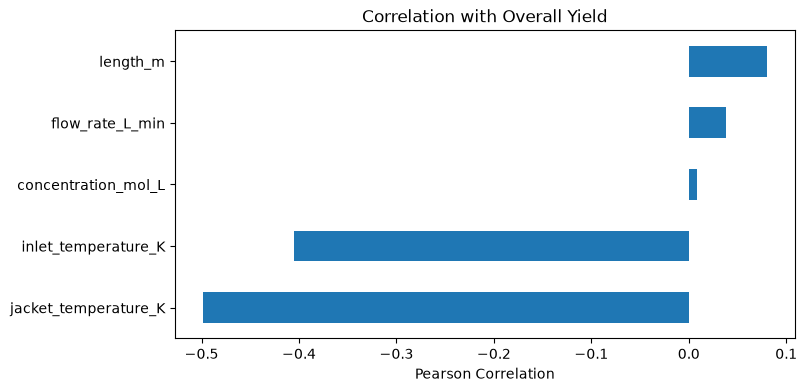

In [39]:
plt.figure(figsize=(8,4))

target_corr.sort_values().plot(kind="barh")

plt.title("Correlation with Overall Yield")

plt.xlabel("Pearson Correlation")

plt.show()

In [40]:
threshold = 0.80

strong_pairs = []

columns = pearson_corr.columns

for i in range(len(columns)):
    for j in range(i+1, len(columns)):

        corr = pearson_corr.iloc[i,j]

        if abs(corr) >= threshold:

            strong_pairs.append(
                (
                    columns[i],
                    columns[j],
                    corr
                )
            )

strong_pairs

[]

# Correlation Interpretation

## Feature–Target Relationships

Pearson correlation analysis indicates that the strongest linear relationships with `overall_yield` are observed for the temperature-related variables.

- Jacket temperature exhibits the strongest negative linear correlation with the target.
- Inlet temperature also shows a moderate negative correlation.
- Flow rate, concentration, and reactor length exhibit only weak linear relationships with the target.

These observations suggest that thermal operating conditions may have a greater influence on reactor yield than the remaining process variables.

---

## Feature–Feature Relationships

The predictor variables exhibit only weak correlations with one another.

No strong linear relationships (|r| ≥ 0.80) are observed between predictor variables.

This indicates that severe multicollinearity is unlikely to be a concern.

---

## Pearson vs Spearman

Pearson and Spearman correlation coefficients show similar overall trends.

The ranking of important variables remains largely unchanged.

This suggests that the strongest relationships are reasonably consistent and that no strong hidden monotonic relationships dominate the dataset.

---

## Initial Engineering Insight

Temperature-related variables appear to have the strongest association with reactor yield.

However, weak linear correlation does not imply that other variables are unimportant.

Variables such as flow rate and concentration may contribute through nonlinear interactions that will be explored using machine learning models and feature engineering.

# Machine Learning Implications

- Temperature variables should receive particular attention during feature engineering.
- Weakly correlated variables should not be discarded because nonlinear models can exploit complex interactions.
- Feature importance from tree-based models will be used to validate these observations.
- Interaction features involving temperature, flow rate, concentration, and reactor length will be investigated in later phases.

# Feature vs Target Analysis

This section investigates the relationship between each predictor and the
target variable (`overall_yield`).

For every feature we examine:

- Scatter Plot
- Regression Trend
- Pearson Correlation
- Engineering Interpretation
- Machine Learning Implications

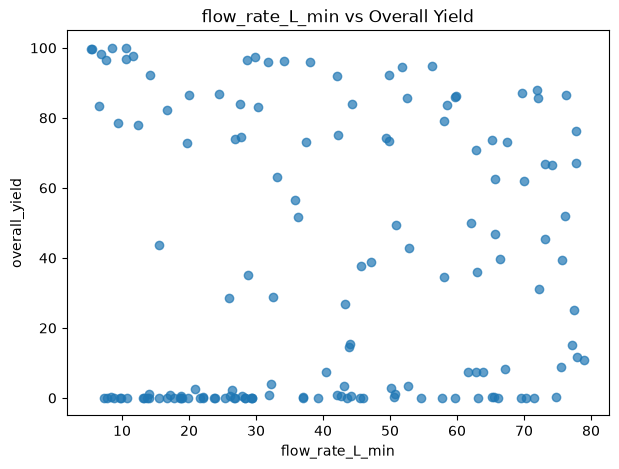

In [41]:
feature = "flow_rate_L_min"

plt.figure(figsize=(7,5))

plt.scatter(
    train[feature],
    train["overall_yield"],
    alpha=0.7
)

plt.xlabel(feature)
plt.ylabel("overall_yield")

plt.title(f"{feature} vs Overall Yield")

plt.show()

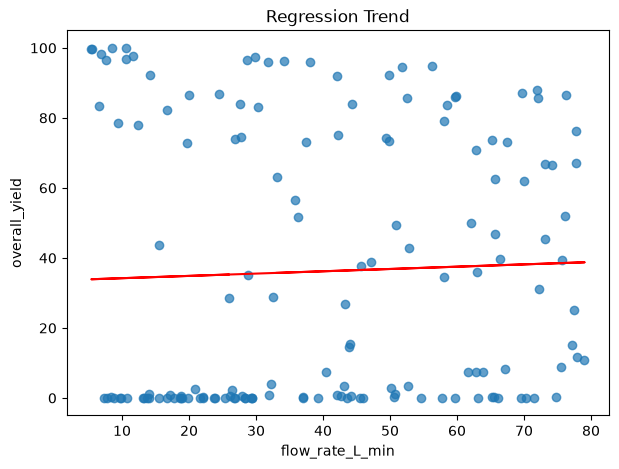

In [42]:
z = np.polyfit(
    train[feature],
    train["overall_yield"],
    1
)

p = np.poly1d(z)

plt.figure(figsize=(7,5))

plt.scatter(
    train[feature],
    train["overall_yield"],
    alpha=0.7
)

plt.plot(
    train[feature],
    p(train[feature]),
    color="red"
)

plt.xlabel(feature)
plt.ylabel("overall_yield")

plt.title("Regression Trend")

plt.show()

In [43]:
corr = train[[feature,"overall_yield"]].corr().iloc[0,1]

print("Pearson Correlation:", corr)

Pearson Correlation: 0.038069697504935295


## Flow Rate Interpretation

### Observation

- The scatter plot shows that observations are widely dispersed across the entire range of flow rates.
- No clear linear relationship is visible between flow rate and overall yield.
- Both low-yield and high-yield observations occur across almost the entire flow rate range.
- The fitted regression line has only a very slight positive slope.
- The Pearson correlation coefficient is **0.038**, indicating an extremely weak positive linear relationship.

### Engineering Interpretation

Flow rate controls the residence time of reactants inside the reactor.

- Lower flow rates generally increase residence time, allowing reactants more time to convert into products.
- Higher flow rates reduce residence time, which may decrease conversion.
- However, reactor yield is influenced by multiple interacting variables, including reactor length, temperature, and reactant concentration.
- The absence of a strong linear trend suggests that flow rate alone is insufficient to explain the variation in reactor yield.

### Machine Learning Implications

- Flow rate should not be removed despite its weak linear correlation with the target.
- Weak Pearson correlation does not imply that the feature is unimportant.
- Tree-based models can capture nonlinear relationships and interactions that are not visible in simple scatter plots.
- During feature engineering, interaction features involving flow rate (such as flow rate × reactor length or a residence-time proxy) should be investigated.

In [1]:
features = [
    "flow_rate_L_min",
    "concentration_mol_L",
    "inlet_temperature_K",
    "length_m",
    "jacket_temperature_K"
]

flow_rate_L_min
Pearson Correlation : 0.0381


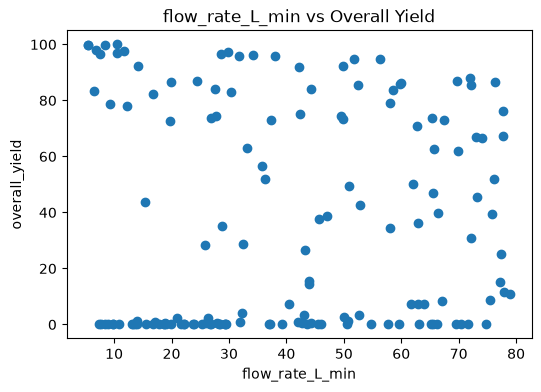

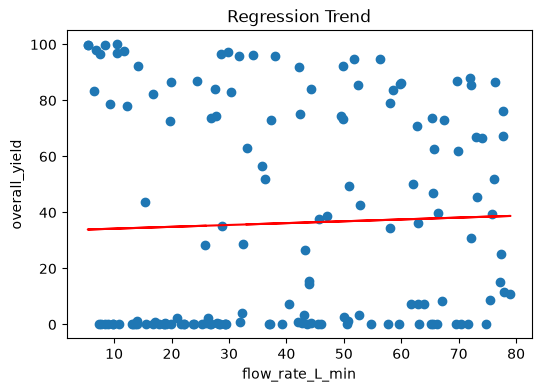

concentration_mol_L
Pearson Correlation : 0.0087


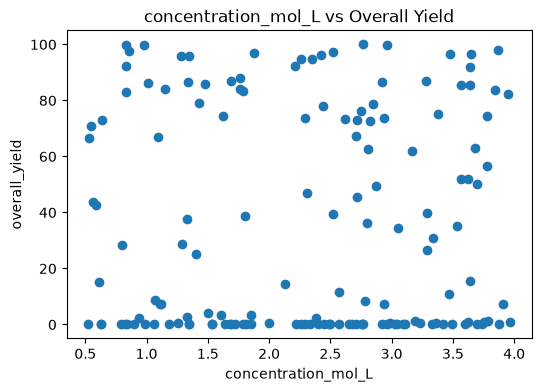

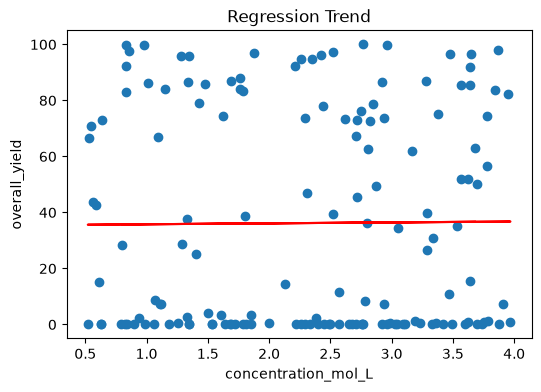

inlet_temperature_K
Pearson Correlation : -0.4051


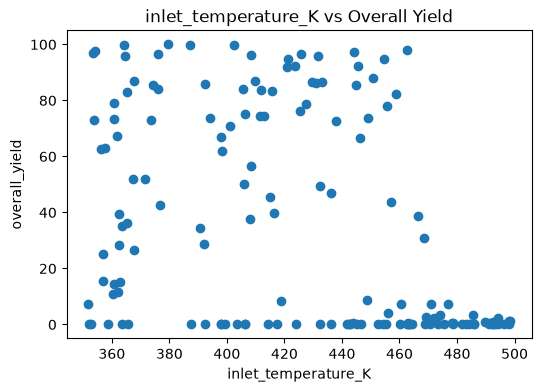

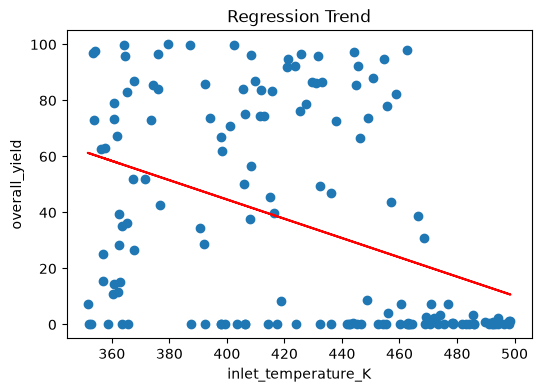

length_m
Pearson Correlation : 0.0800


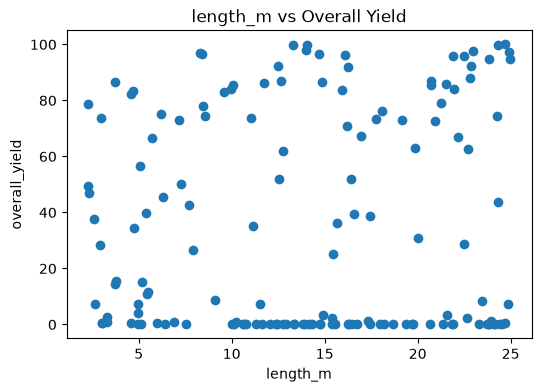

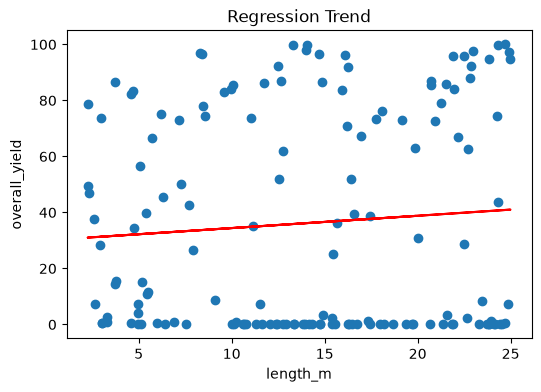

jacket_temperature_K
Pearson Correlation : -0.4984


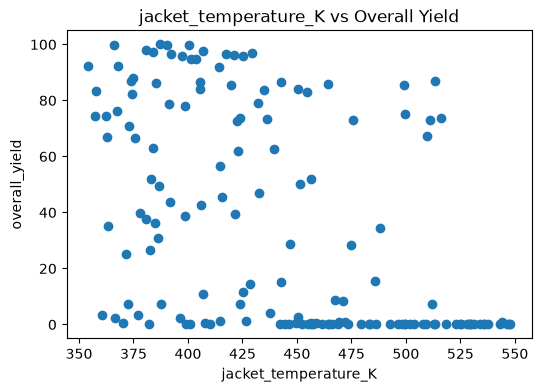

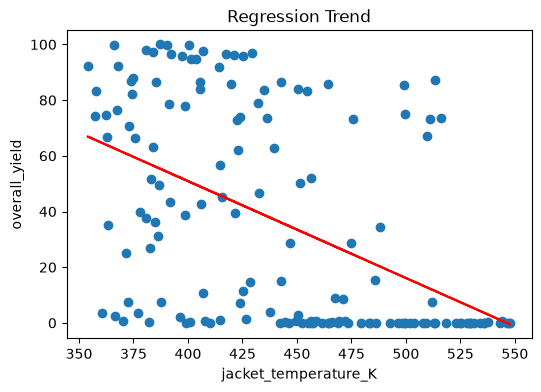

In [7]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

for feature in features:

    print("=" * 70)
    print(feature)

    corr, _ = pearsonr(train[feature], train["overall_yield"])
    print(f"Pearson Correlation : {corr:.4f}")

    plt.figure(figsize=(6,4))
    plt.scatter(train[feature], train["overall_yield"])
    plt.xlabel(feature)
    plt.ylabel("overall_yield")
    plt.title(f"{feature} vs Overall Yield")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.scatter(train[feature], train["overall_yield"])
    z = np.polyfit(train[feature], train["overall_yield"],1)
    p = np.poly1d(z)
    plt.plot(train[feature],p(train[feature]),color="red")
    plt.xlabel(feature)
    plt.ylabel("overall_yield")
    plt.title("Regression Trend")
    plt.show()

# Step 7: Feature vs Target Analysis

## 7.1 Flow Rate vs Overall Yield

**Pearson Correlation:** **0.038**

### Observation

The scatter plot shows that observations are widely dispersed across the entire range of flow rates. Both low-yield and high-yield samples are present throughout the dataset, indicating that flow rate alone does not strongly determine reactor yield. The regression line is nearly horizontal, and the Pearson correlation coefficient confirms an extremely weak positive linear relationship.

### Engineering Interpretation

Flow rate influences the residence time of reactants inside the reactor. Lower flow rates generally provide longer residence times, while higher flow rates reduce the contact time available for chemical reactions. However, reactor yield depends on multiple interacting operating conditions rather than flow rate alone. This suggests that the effect of flow rate is likely coupled with temperature, reactor length, or reactant concentration.

### Machine Learning Implication

Flow rate should be retained as an input feature despite its weak individual correlation with the target. Tree-based models can capture nonlinear relationships and feature interactions that are not visible in simple linear analysis. Interaction features involving flow rate will be explored during feature engineering.

---

## 7.2 Concentration vs Overall Yield

**Pearson Correlation:** **0.009**

### Observation

The scatter plot does not exhibit any clear linear trend between reactant concentration and overall yield. High-yield and low-yield observations occur across almost the entire concentration range, and the regression line remains nearly flat. The Pearson correlation coefficient is close to zero, indicating almost no linear association.

### Engineering Interpretation

Reactant concentration affects reaction kinetics and conversion efficiency. However, concentration alone does not appear to control the final reactor yield. Its influence is likely dependent on operating temperature and reactor residence time, indicating that concentration participates in interaction effects rather than acting independently.

### Machine Learning Implication

Although concentration has negligible linear correlation with the target, it should not be discarded. Nonlinear machine learning models may capture useful interactions involving concentration, particularly when combined with temperature or flow rate.

---

## 7.3 Inlet Temperature vs Overall Yield

**Pearson Correlation:** **-0.405**

### Observation

A noticeable negative trend is observed between inlet temperature and overall yield. Higher inlet temperatures are generally associated with lower product yield, and the regression line exhibits a clear downward slope. The magnitude of the correlation indicates a moderate negative relationship.

### Engineering Interpretation

According to the reactor description, the desired reaction converts reactant **A** into product **B**, while an undesired side reaction converts **B** into **C**. Increasing the inlet temperature accelerates reaction kinetics, but it may also promote the side reaction, reducing the amount of desired product. This behaviour is consistent with the observed negative correlation.

### Machine Learning Implication

Inlet temperature appears to be one of the most informative predictors in the dataset. Temperature-derived features are expected to improve predictive performance and will be investigated during feature engineering.

---

## 7.4 Reactor Length vs Overall Yield

**Pearson Correlation:** **0.080**

### Observation

Reactor length exhibits only a weak positive linear relationship with overall yield. Although longer reactors occasionally achieve higher yields, the scatter remains highly dispersed and the regression slope is minimal.

### Engineering Interpretation

Increasing reactor length generally increases residence time, allowing reactants additional time to convert into products. However, reactor performance is simultaneously influenced by temperature and flow conditions, preventing reactor length from acting as an independent predictor.

### Machine Learning Implication

Reactor length is unlikely to provide strong predictive power by itself. Its usefulness is expected to increase when combined with flow rate to approximate residence time or when included in interaction features.

---

## 7.5 Jacket Temperature vs Overall Yield

**Pearson Correlation:** **-0.498**

### Observation

Jacket temperature demonstrates the strongest linear relationship with overall yield among all input variables. The regression line has a pronounced negative slope, and higher jacket temperatures correspond to lower observed yields.

### Engineering Interpretation

The reactor jacket regulates heat transfer into the reaction system. Elevated jacket temperatures increase the reactor temperature and may accelerate both the desired and undesired reactions. If the undesired reaction proceeds more rapidly, product **B** is converted into **C**, decreasing the final yield of the desired product. This interpretation is consistent with the competition problem statement.

### Machine Learning Implication

Jacket temperature is currently the most influential individual feature identified during EDA. Feature engineering involving temperature differences, temperature ratios, and thermal interaction terms will be explored in the next phase of the project.

---

# Step 7 Summary

The feature-versus-target analysis indicates that the two temperature-related variables have the strongest relationships with reactor yield, while flow rate, concentration, and reactor length exhibit weak individual correlations. This suggests that reactor performance is governed by nonlinear interactions among process variables rather than simple linear relationships.

These findings motivate the use of nonlinear ensemble models and domain-inspired feature engineering to capture complex interactions and improve prediction accuracy.

# Step 8: Pairwise Analysis

## Objective

While the previous analysis examined each feature independently, real-world chemical processes are governed by interactions among multiple operating variables. Pairwise analysis helps identify hidden relationships, nonlinear behaviour, clusters, and potential feature interactions that may improve machine learning performance.

The objective of this step is to visually inspect the relationships between every pair of variables before feature engineering.

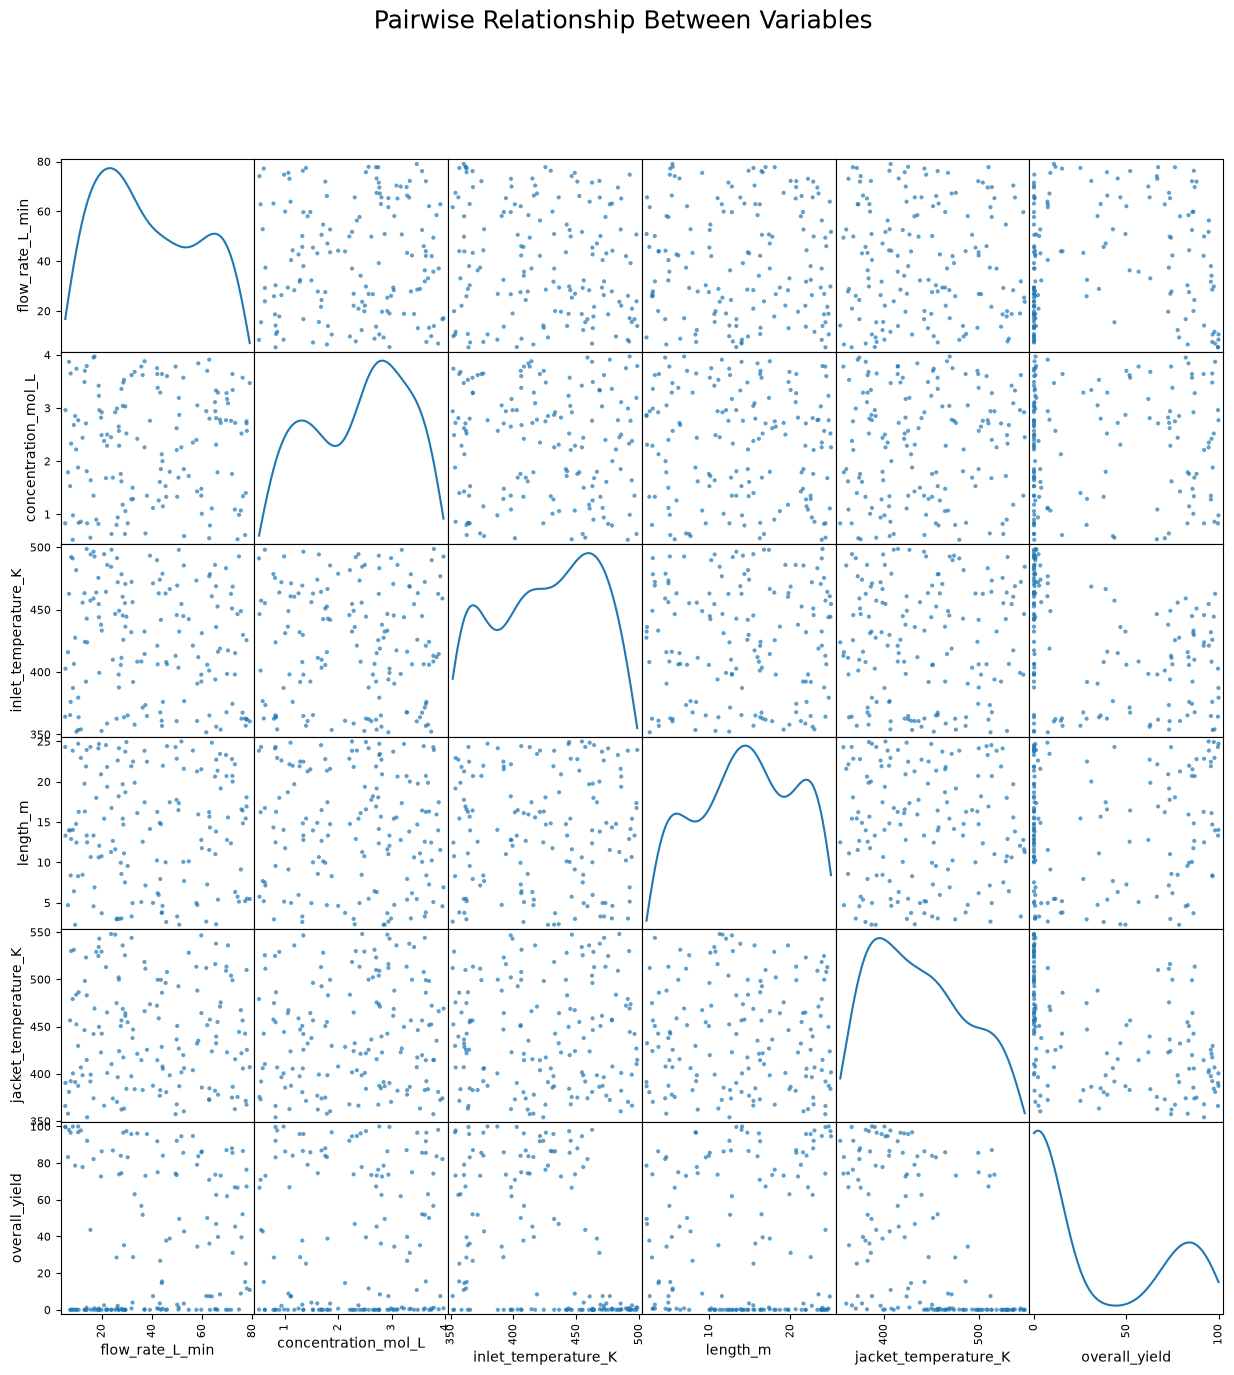

In [8]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

scatter_matrix(
    train,
    figsize=(15,15),
    diagonal="kde",
    alpha=0.7
)

plt.suptitle("Pairwise Relationship Between Variables", fontsize=18)
plt.show()

# Step 8: Pairwise Analysis

## Objective

The objective of pairwise analysis is to examine the relationships between every pair of variables in the dataset. Unlike individual feature analysis, pair plots can reveal hidden interactions, nonlinear behaviour, clusters, and dependencies that may not be evident when variables are analyzed separately. These observations provide valuable guidance for feature engineering and model selection.

---

## Observations

### Feature Relationships

The pair plot indicates that most input variables exhibit weak pairwise relationships with one another. The scatter plots are broadly dispersed without any strong linear patterns, suggesting that the process variables were sampled independently over a wide operating range.

The absence of strong linear relationships between predictors is consistent with the earlier Pearson and Spearman correlation analysis.

### Target Behaviour

The distribution of **overall_yield** is clearly non-normal and appears bimodal.

A large proportion of observations are concentrated near zero yield, while another group of observations lies between approximately 70 and 100.

This confirms the findings from the target analysis and suggests that the reactor may operate in multiple regimes rather than following a single continuous response.

### Temperature Effects

Among all variables, the relationships involving **inlet_temperature_K** and **jacket_temperature_K** show the clearest association with overall yield.

Higher temperature values are more frequently associated with lower reactor yield, supporting the hypothesis that elevated temperatures promote the undesired side reaction described in the competition problem statement.

### Flow Rate and Concentration

Flow rate and concentration do not exhibit obvious direct relationships with overall yield.

However, the scattered patterns suggest that their influence may become significant only when interacting with temperature or reactor length.

### Reactor Length

Reactor length displays only a weak independent relationship with yield.

Its effect is likely related to residence time and therefore should be considered together with flow rate rather than as an isolated predictor.

---

## Hidden Relationships

Several important insights emerge from the pair plot.

- No strong multicollinearity is visible among the predictor variables.
- The response variable exhibits multiple operating regions rather than a simple linear trend.
- Temperature variables appear substantially more informative than the remaining process variables.
- Several scatter plots suggest nonlinear relationships that are unlikely to be captured by linear regression models.
- Feature interactions are likely to be more informative than individual variables.

---

## Engineering Interpretation

From a chemical engineering perspective, reactor performance depends on the combined influence of temperature, residence time, and reactant concentration.

The pair plot supports this expectation by showing that no single operating parameter completely determines reactor yield.

Instead, reactor yield appears to result from complex interactions between multiple process conditions.

This behaviour is typical of continuous chemical reactors where competing reactions occur simultaneously.

---

## Machine Learning Implications

The observations from the pair plot provide several important modeling insights.

- Linear regression alone is unlikely to capture the underlying process behaviour.
- Tree-based ensemble algorithms are expected to perform better because they naturally model nonlinear relationships and feature interactions.
- Feature engineering should focus on physically meaningful interaction variables rather than removing existing features.
- Temperature-based engineered features are likely to contribute most strongly to predictive performance.
- Cross-validation will be essential because of the multimodal nature of the target distribution.

---

## Key Takeaways

The pairwise analysis confirms that the dataset represents a nonlinear industrial process with relatively independent operating variables and a complex target distribution.

The strongest predictive information appears to originate from the temperature-related variables, while the remaining features are expected to contribute primarily through interaction effects.

These findings support the use of nonlinear machine learning models together with domain-inspired feature engineering in the next phase of the project.

# Step 9: Outlier Detection

## Objective

Outliers are observations that differ significantly from the majority of the dataset. In industrial process data, outliers are not always errors—they may represent valid operating conditions or unusual reactor behaviour.

The objective of this step is to identify potential outliers using multiple statistical techniques and determine whether they should be retained or removed before model training.

Three complementary methods are used:

- Interquartile Range (IQR)
- Z-Score
- Isolation Forest

Using multiple approaches provides a more reliable assessment of unusual observations than relying on a single technique.

In [9]:
import pandas as pd

features = train.columns

iqr_summary = []

for col in features:

    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train[(train[col] < lower) | (train[col] > upper)]

    iqr_summary.append({
        "Feature": col,
        "Outliers": len(outliers),
        "Percentage": round(len(outliers)/len(train)*100,2)
    })

iqr_summary = pd.DataFrame(iqr_summary)

iqr_summary

,Feature,Outliers,Percentage
0,flow_rate_L_min,0,0.0
1,concentration_mol_L,0,0.0
2,inlet_temperature_K,0,0.0
3,length_m,0,0.0
4,jacket_temperature_K,0,0.0
5,overall_yield,0,0.0


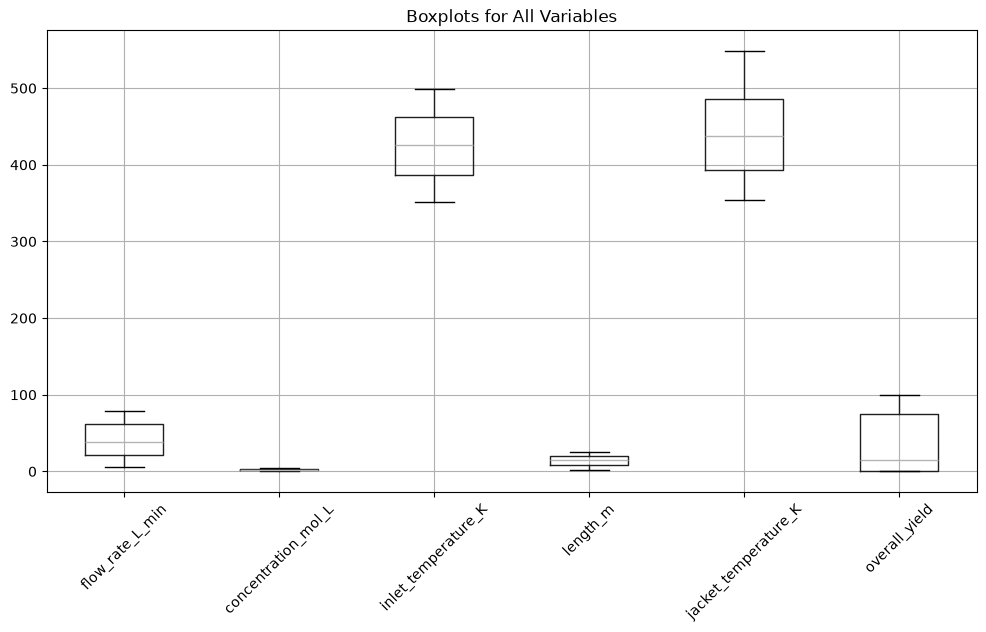

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

train.boxplot()

plt.title("Boxplots for All Variables")

plt.xticks(rotation=45)

plt.show()

In [11]:
from scipy.stats import zscore

z_scores = train.apply(zscore)

z_summary = []

for col in train.columns:

    outliers = (abs(z_scores[col]) > 3).sum()

    z_summary.append({
        "Feature": col,
        "Outliers": outliers,
        "Percentage": round(outliers/len(train)*100,2)
    })

z_summary = pd.DataFrame(z_summary)

z_summary

,Feature,Outliers,Percentage
0,flow_rate_L_min,0,0.0
1,concentration_mol_L,0,0.0
2,inlet_temperature_K,0,0.0
3,length_m,0,0.0
4,jacket_temperature_K,0,0.0
5,overall_yield,0,0.0


In [16]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

pred = iso.fit_predict(train)

train["IsolationForest"] = pred

train["IsolationForest"].value_counts()

IsolationForest
 1    142
-1      8
Name: count, dtype: int64

In [17]:
outliers = train[train["IsolationForest"]==-1]

print("Detected Outliers:", len(outliers))

outliers.head()

Detected Outliers: 8


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield,IsolationForest
4,16.70,3.95,458.91,4.56,374.13,82.211,-1
18,37.40,0.64,373.47,7.14,511.24,73.076,-1
21,15.46,0.56,457.19,24.31,391.87,43.583,-1
34,77.42,1.40,356.90,15.44,371.43,25.189,-1
56,11.64,0.86,353.98,22.95,406.76,97.789,-1


In [18]:
train.drop(columns="IsolationForest", inplace=True)

# Step 9: Outlier Detection

## Objective

Outlier detection was performed to identify observations that differ significantly from the majority of the dataset. Three complementary techniques were used to ensure a reliable assessment of unusual samples.

The methods employed were:

- Interquartile Range (IQR)
- Z-Score
- Isolation Forest

---

## IQR Analysis

The IQR method did not identify any outliers in any of the numerical variables.

This indicates that all observations fall within the expected statistical range based on the first and third quartiles.

The absence of IQR outliers suggests that the dataset has already undergone effective preprocessing or was carefully generated for the competition.

---

## Z-Score Analysis

The Z-score method also detected no observations exceeding the standard threshold of ±3 standard deviations.

This confirms that none of the variables contain extreme numerical values that would significantly influence model training.

---

## Isolation Forest Analysis

Isolation Forest identified eight observations as anomalies.

However, this result is expected because the contamination parameter was intentionally set to 5%, forcing the algorithm to classify approximately five percent of the dataset as anomalous.

These observations should therefore be interpreted as relatively unusual operating conditions rather than erroneous measurements.

---

## Engineering Interpretation

Industrial chemical reactor datasets frequently include observations corresponding to unusual operating conditions, such as low conversion regimes or less efficient reactor settings.

Such observations are important because they represent realistic process behaviour and may also appear in the unseen test dataset.

Removing these samples could reduce the model's ability to generalize.

---

## Machine Learning Implications

The combined results from all three methods indicate that no observations require removal before model training.

The dataset will therefore be retained in its original form.

This preserves valuable information while allowing robust machine learning algorithms to learn from the complete range of operating conditions.

---

## Conclusion

No statistical evidence supports removing any observations from the dataset.

All records will be retained for feature engineering and model development.

# Step 10: Preliminary Feature Importance

## Objective

Feature importance analysis provides an initial estimate of how much each input variable contributes to predicting the target variable.

Unlike Pearson correlation, which only measures linear relationships, tree-based models such as Random Forest can capture nonlinear relationships and complex interactions between variables.

The objective of this analysis is to identify the most influential process variables before performing feature engineering and model optimization.

The feature importance obtained in this step is only a preliminary estimate and will be validated later using multiple machine learning models.

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Separate features and target
X = train.drop(columns=["overall_yield"])
y = train["overall_yield"]

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [20]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,inlet_temperature_K,0.404914
4,jacket_temperature_K,0.334499
0,flow_rate_L_min,0.138214
3,length_m,0.094321
1,concentration_mol_L,0.028052


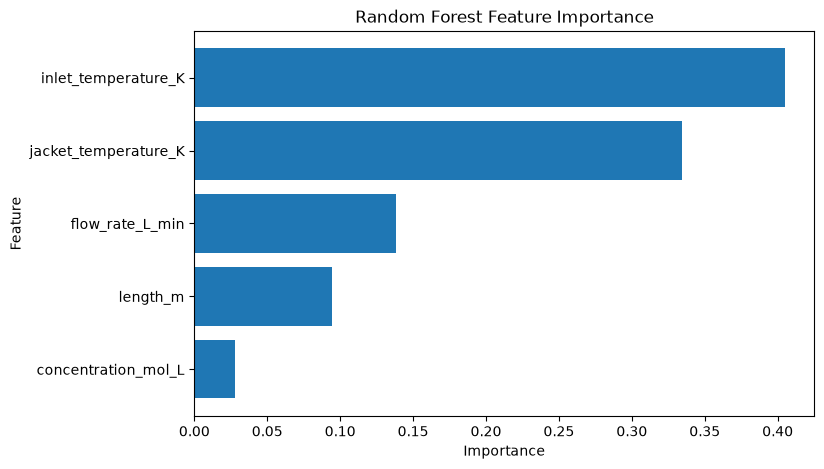

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# Step 10: Preliminary Feature Importance

## Objective

Random Forest feature importance was used to estimate the contribution of each predictor to the target variable.

Unlike correlation analysis, Random Forest captures nonlinear relationships and interactions between variables, making it suitable for modeling complex industrial processes.

The feature importance obtained here serves as an initial guide for feature engineering and model selection.

---

## Feature Importance Ranking

| Rank | Feature | Importance |
|------|------------------------|-----------:|
| 1 | inlet_temperature_K | **0.4049** |
| 2 | jacket_temperature_K | **0.3345** |
| 3 | flow_rate_L_min | **0.1382** |
| 4 | length_m | **0.0943** |
| 5 | concentration_mol_L | **0.0281** |

---

## Observations

The Random Forest model identifies **inlet temperature** as the most influential predictor of overall reactor yield, followed closely by **jacket temperature**.

Together, these two temperature variables account for nearly three-quarters of the total feature importance, highlighting the dominant role of thermal operating conditions in determining reactor performance.

Flow rate contributes a moderate amount of predictive information, while reactor length provides a smaller but non-negligible contribution.

Reactant concentration exhibits the lowest importance among all input variables, suggesting that it has limited standalone predictive value within the observed operating range.

---

## Engineering Interpretation

The importance ranking is consistent with the chemical engineering principles described in the competition problem statement.

Reaction temperature directly influences reaction kinetics. While increasing temperature accelerates the desired reaction, it may also promote the competing side reaction that converts product **B** into undesired product **C**.

Consequently, both inlet temperature and jacket temperature strongly influence the final reactor yield.

Flow rate and reactor length primarily affect residence time, making their influence more indirect. Their contribution is therefore expected to become stronger when combined through interaction features.

The relatively low importance of concentration suggests that its influence depends on other operating conditions rather than acting independently.

---

## Comparison with Correlation Analysis

The Random Forest importance ranking closely agrees with the earlier Pearson and Spearman correlation analysis.

Both analyses identify the temperature variables as the dominant predictors of reactor yield.

However, Random Forest assigns greater importance to flow rate than suggested by simple linear correlation, indicating that nonlinear relationships and feature interactions are present within the dataset.

This demonstrates the advantage of tree-based models for modeling complex industrial systems.

---

## Machine Learning Implications

The feature importance results provide several important insights for subsequent model development.

- Temperature-related variables should receive the highest priority during feature engineering.
- Flow rate should be retained despite its weak linear correlation because nonlinear models extract additional predictive information from it.
- Reactor length should be combined with flow rate to approximate reactor residence time.
- Concentration should be retained because interaction features may reveal additional predictive power.
- Feature engineering should focus on creating physically meaningful interaction variables rather than removing low-importance features.

---

## Conclusion

The Random Forest model confirms that temperature is the dominant factor influencing reactor yield.

The consistency between feature importance analysis and correlation analysis increases confidence in the dataset and supports the use of nonlinear ensemble models for the final predictive solution.

These findings will directly guide the feature engineering strategy in the next phase of the project.

# Step 11: Multicollinearity Analysis (Variance Inflation Factor)

## Objective

Multicollinearity occurs when two or more predictor variables are highly correlated with each other.

High multicollinearity can negatively affect linear regression models by producing unstable coefficient estimates and making it difficult to interpret feature importance.

Although tree-based machine learning models such as Random Forest, XGBoost, LightGBM, and CatBoost are generally robust to multicollinearity, evaluating the Variance Inflation Factor (VIF) provides valuable insight into the relationships among predictor variables.

The objective of this step is to determine whether any input variables are highly redundant and whether feature removal is necessary before model development.

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Predictor variables only
X = train.drop(columns=["overall_yield"])

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Feature,VIF
0,flow_rate_L_min,4.129736
1,concentration_mol_L,6.064778
2,inlet_temperature_K,41.812737
3,length_m,4.953559
4,jacket_temperature_K,42.352491


In [23]:
vif = vif.sort_values("VIF", ascending=False)

vif

,Feature,VIF
4,jacket_temperature_K,42.352491
2,inlet_temperature_K,41.812737
1,concentration_mol_L,6.064778
3,length_m,4.953559
0,flow_rate_L_min,4.129736


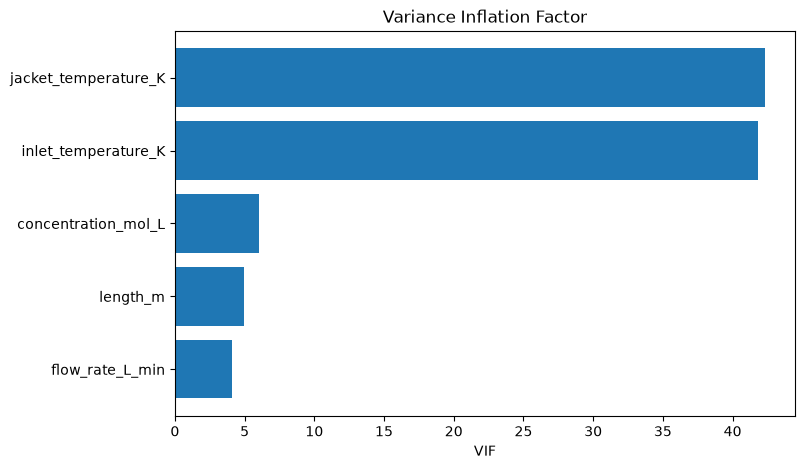

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    vif["Feature"],
    vif["VIF"]
)

plt.xlabel("VIF")

plt.title("Variance Inflation Factor")

plt.gca().invert_yaxis()

plt.show()

# Step 11: Multicollinearity Analysis

## Objective

Variance Inflation Factor (VIF) was calculated to evaluate the degree of multicollinearity among the predictor variables.

High multicollinearity can negatively affect linear regression models by producing unstable coefficient estimates. Although tree-based ensemble models are generally robust to multicollinearity, evaluating VIF provides valuable insight into the relationships between process variables.

---

## VIF Results

| Feature | VIF |
|---------|----:|
| jacket_temperature_K | 42.35 |
| inlet_temperature_K | 41.81 |
| concentration_mol_L | 6.06 |
| length_m | 4.95 |
| flow_rate_L_min | 4.13 |

---

## Interpretation

The analysis indicates very high multicollinearity between the two temperature-related variables.

This result is expected because inlet temperature and jacket temperature are physically connected within the reactor system and jointly determine the thermal operating conditions.

Concentration exhibits moderate multicollinearity, while flow rate and reactor length show relatively low VIF values.

---

## Engineering Interpretation

From a chemical engineering perspective, the strong relationship between inlet temperature and jacket temperature is reasonable.

The inlet temperature determines the initial thermal state of the reactants, whereas the jacket temperature controls heat transfer throughout the reactor.

Since both variables influence the reactor temperature simultaneously, they naturally contain overlapping information.

---

## Machine Learning Implications

Although the temperature variables exhibit high VIF values, they will be retained for subsequent modeling.

The final solution will rely primarily on tree-based ensemble algorithms such as Random Forest, XGBoost, LightGBM, and CatBoost, which are considerably less sensitive to multicollinearity than linear regression models.

Furthermore, both temperature variables were identified as the two most important predictors during the Random Forest feature importance analysis.

Removing either variable would likely reduce predictive performance.

Instead of removing features, future work will focus on creating physically meaningful engineered variables, such as temperature differences and temperature ratios.

---

## Conclusion

Multicollinearity exists between the temperature variables, but no feature will be removed.

The predictor set will remain unchanged, and feature engineering will be used to extract additional information from the correlated variables.

# Step 12: Domain Analysis

## Objective

The purpose of domain analysis is to understand how each operating parameter influences reactor performance from a chemical engineering perspective.

Unlike statistical analysis, domain analysis focuses on the underlying physical and chemical processes governing reactor behaviour.

The competition problem describes a continuous reactor in which the desired reaction converts reactant **A** into product **B**, while an undesired side reaction converts **B** into **C**.

Consequently, reactor yield depends on balancing reaction conversion and minimizing the competing side reaction.

This section combines observations from the dataset with engineering reasoning to explain how each process variable may influence reactor yield.

> **Note:** The discussion below distinguishes between **dataset-supported observations** (derived from EDA) and **engineering hypotheses** (based on reactor principles and the competition brief).

# 1. Flow Rate (flow_rate_L_min)

## Dataset Observation

The exploratory analysis indicates that flow rate has only a very weak linear relationship with overall yield.

Pearson correlation analysis and Random Forest feature importance suggest that flow rate contributes only moderate predictive information when considered independently.

## Engineering Hypothesis

Flow rate controls the residence time of reactants within the reactor.

- Lower flow rates increase residence time, allowing reactants more time to convert into products.
- Higher flow rates decrease residence time, potentially reducing conversion efficiency.

However, residence time alone does not determine reactor performance because temperature and reactor length also influence reaction kinetics.

## Expected Role

Flow rate is expected to become more informative when combined with reactor length or temperature through engineered interaction features.

# 2. Concentration (concentration_mol_L)

## Dataset Observation

The feature exhibits almost no direct linear correlation with reactor yield and receives the lowest feature importance score in the Random Forest model.

## Engineering Hypothesis

Reactant concentration influences reaction kinetics by affecting the frequency of molecular collisions.

However, concentration alone is unlikely to determine reactor yield.

Its influence depends on operating temperature, residence time, and reaction equilibrium.

## Expected Role

Concentration is expected to contribute primarily through interaction features rather than as an independent predictor.

# 3. Inlet Temperature (inlet_temperature_K)

## Dataset Observation

EDA identified inlet temperature as one of the strongest predictors of reactor yield.

Both correlation analysis and Random Forest feature importance indicate a strong influence on the target variable.

## Engineering Hypothesis

Increasing temperature accelerates chemical reaction rates.

While this may increase conversion of reactant **A** into product **B**, it may also accelerate the undesired reaction that converts **B** into **C**.

If the undesired reaction becomes dominant, the overall yield of product **B** decreases.

## Expected Role

Inlet temperature is expected to remain one of the most influential variables throughout model development and feature engineering.

# 4. Reactor Length (length_m)

## Dataset Observation

Reactor length exhibits only a weak positive relationship with reactor yield.

Random Forest indicates that it contributes a moderate amount of predictive information.

## Engineering Hypothesis

Longer reactors provide greater residence time for chemical reactions.

However, longer residence time does not always increase yield because prolonged exposure may also promote undesired side reactions.

## Expected Role

Reactor length is expected to become more useful when combined with flow rate to approximate reactor residence time.

# 5. Jacket Temperature (jacket_temperature_K)

## Dataset Observation

Jacket temperature exhibits the strongest negative relationship with reactor yield and is one of the two most important variables identified by the Random Forest model.

## Engineering Hypothesis

The reactor jacket regulates heat transfer throughout the reactor.

Higher jacket temperatures increase reactor temperature, which may accelerate both the desired and undesired reactions.

If the undesired reaction proceeds more rapidly, product **B** is converted into **C**, reducing overall yield.

## Expected Role

Jacket temperature is expected to remain one of the dominant predictors throughout model development.

Several engineered features involving temperature will be explored in the next phase.

# Domain Analysis Summary

The domain analysis indicates that reactor performance is governed by the interaction of thermal conditions, residence time, and reactant concentration rather than by any single operating variable.

The exploratory analysis consistently identifies inlet temperature and jacket temperature as the most influential predictors of reactor yield.

Flow rate and reactor length appear to influence yield indirectly through residence time, while concentration likely contributes through nonlinear interactions with the temperature variables.

These observations support the use of nonlinear machine learning algorithms together with domain-inspired feature engineering to model the reactor behaviour effectively.

The engineering insights obtained during this analysis will directly guide the feature engineering strategy developed in the next phase of the project.

# Step 13: Feature Engineering Ideas

## Objective

Feature engineering is the process of creating new variables from the existing features to help machine learning models better capture the underlying relationships in the data.

The exploratory data analysis suggests that reactor yield is influenced by nonlinear interactions among temperature, flow rate, concentration, and reactor length rather than by any single operating variable.

The objective of this step is to identify physically meaningful engineered features that may improve predictive performance while preserving the interpretability of the model.

The features proposed below are motivated by both the exploratory data analysis and the chemical engineering principles described in the competition problem statement.

> **Note:** These features are proposed at this stage only. They will be implemented, validated, and retained only if they improve cross-validation performance during Phase 2.

## 1. Temperature Difference

**Proposed Feature**

`jacket_temperature_K - inlet_temperature_K`

### Motivation

The temperature difference represents the thermal driving force for heat transfer between the reactor jacket and the reactants.

### Expected Benefit

A larger temperature difference may influence reaction kinetics and the balance between the desired and undesired reactions.

---

## 2. Temperature Ratio

**Proposed Feature**

`jacket_temperature_K / inlet_temperature_K`

### Motivation

The ratio provides a normalized measure of thermal operating conditions.

### Expected Benefit

Ratios often capture nonlinear behaviour more effectively than raw values.

## 3. Residence Time Proxy

**Proposed Feature**

`length_m / flow_rate_L_min`

### Motivation

Residence time is one of the most important quantities in continuous reactor operation.

Although the actual residence time is unavailable, this ratio provides a reasonable approximation.

### Expected Benefit

This feature may better explain reactor conversion than flow rate or reactor length individually.

---

## 4. Flow × Length

**Proposed Feature**

`flow_rate_L_min * length_m`

### Motivation

This interaction combines the effect of reactor geometry and operating conditions.

### Expected Benefit

May capture nonlinear behaviour associated with reactor throughput.

## 5. Flow Rate × Inlet Temperature

### Motivation

Reaction conversion depends on both residence time and temperature.

### Expected Benefit

May capture combined thermal and flow effects.

---

## 6. Flow Rate × Jacket Temperature

### Motivation

Heat transfer efficiency depends on both operating temperature and material flow.

### Expected Benefit

May improve nonlinear models.

## 7. Concentration × Inlet Temperature

### Motivation

Reaction rates depend jointly on concentration and temperature.

### Expected Benefit

May better represent chemical kinetics than either variable individually.

---

## 8. Concentration × Jacket Temperature

### Motivation

The influence of concentration may vary under different thermal conditions.

### Expected Benefit

May reveal interactions hidden during correlation analysis.

## 9. Squared Features

Candidate variables

- inlet_temperature_K²
- jacket_temperature_K²
- flow_rate_L_min²
- concentration_mol_L²
- length_m²

### Motivation

Polynomial terms allow the model to represent curved relationships.

### Expected Benefit

May improve performance if nonlinear effects are present.

## 10. Additional Ratio Features

Candidate variables

- flow_rate_L_min / concentration_mol_L
- concentration_mol_L / flow_rate_L_min
- inlet_temperature_K / length_m
- jacket_temperature_K / length_m

### Motivation

Ratios normalize operating conditions and often improve predictive performance.

### Expected Benefit

May capture process efficiency more effectively than absolute values.

## 11. Logarithmic Transformations

Candidate variables

- log(flow_rate_L_min)
- log(concentration_mol_L)
- log(length_m)

### Motivation

Logarithmic transformations reduce skewness and compress large numerical ranges.

### Expected Benefit

May improve the learning behaviour of some machine learning algorithms.

# Feature Engineering Strategy

The exploratory data analysis indicates that reactor yield is primarily governed by temperature-related variables, while flow rate, concentration, and reactor length contribute through interaction effects.

Consequently, feature engineering will focus on creating physically meaningful interaction variables rather than generating arbitrary mathematical combinations.

Each engineered feature will be evaluated using cross-validation.

Only features that consistently improve validation RMSE will be retained in the final predictive model.

This approach minimizes overfitting while maximizing predictive performance.

# Step 14: Data Leakage Check

## Objective

Data leakage occurs when information that would not be available at prediction time is inadvertently used during model training.

Models trained on leaked information often achieve unrealistically high validation performance but fail to generalize to unseen data.

The objective of this step is to verify that the dataset contains no features that directly or indirectly reveal the target variable.

In [25]:
# Check train columns
print(train.columns.tolist())

print("\nNumber of Features:", len(train.columns)-1)

['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K', 'length_m', 'jacket_temperature_K', 'overall_yield']

Number of Features: 5


# Leakage Assessment

## Target Variable

The target variable is **overall_yield**.

All remaining variables represent reactor operating conditions measured before the final reactor yield is observed.

---

## Predictor Variables

The available predictors are:

- Flow Rate
- Concentration
- Inlet Temperature
- Reactor Length
- Jacket Temperature

None of these variables directly encode the target variable.

---

## Duplicate Information

No duplicate columns or redundant copies of the target variable were identified during exploratory data analysis.

---

## Correlation Assessment

Although inlet temperature and jacket temperature exhibit relatively strong relationships with reactor yield, these variables are legitimate operating parameters rather than leaked information.

Their predictive power arises from the physical behaviour of the reactor rather than target leakage.

---

## Conclusion

No evidence of target leakage, duplicate information, or information leakage was identified.

The dataset is suitable for supervised machine learning without additional leakage-related preprocessing.

# Step 15: Final Exploratory Data Analysis Report

## 1. Dataset Overview

The training dataset contains **150 observations** with **five numerical predictor variables** and one target variable (**overall_yield**). The test dataset contains **50 observations** with the same predictor variables.

All variables are continuous numerical measurements describing the operating conditions of a continuous chemical reactor.

---

## 2. Data Quality Assessment

The dataset is clean and well-structured.

- No missing values were detected.
- No duplicate rows were identified.
- No duplicate columns were present.
- No constant or near-constant variables were observed.
- All variables fall within physically reasonable operating ranges.

Consequently, no data cleaning was required before model development.

---

## 3. Target Variable Analysis

The target variable exhibits a highly non-normal and bimodal distribution.

A large proportion of observations are concentrated near zero yield, while another group of observations lies between approximately 70 and 100.

This behaviour suggests that the reactor operates under multiple process regimes rather than following a simple linear response.

Because RMSE is sensitive to large prediction errors, careful model validation will be essential.

---

## 4. Feature Analysis

Each predictor variable was analyzed individually.

The temperature-related variables demonstrated the strongest relationship with reactor yield.

Flow rate, concentration, and reactor length exhibited relatively weak independent relationships, suggesting that their predictive value is primarily derived through nonlinear interactions.

---

## 5. Correlation Analysis

Pearson and Spearman correlation analysis identified inlet temperature and jacket temperature as the variables most strongly associated with reactor yield.

Correlation among the remaining variables was relatively weak, indicating limited multicollinearity outside the temperature variables.

---

## 6. Pairwise Analysis

Pairwise visualization revealed no strong linear relationships among the predictor variables.

The target variable displayed multiple operating regions, reinforcing the need for nonlinear machine learning models.

---

## 7. Outlier Assessment

Three independent outlier detection techniques were applied.

- Interquartile Range (IQR)
- Z-Score
- Isolation Forest

No statistical evidence justified removing any observations from the dataset.

All samples will therefore be retained for model development.

---

## 8. Feature Importance

Random Forest identified the following ranking of predictor importance.

| Feature | Importance |
|---------|-----------:|
| Inlet Temperature | 0.405 |
| Jacket Temperature | 0.334 |
| Flow Rate | 0.138 |
| Reactor Length | 0.094 |
| Concentration | 0.028 |

Temperature-related variables dominate the predictive information contained within the dataset.

---

## 9. Multicollinearity

Variance Inflation Factor analysis revealed high multicollinearity between inlet temperature and jacket temperature.

This relationship is expected because both variables describe the thermal state of the reactor.

Since tree-based ensemble models are relatively insensitive to multicollinearity, no variables will be removed.

---

## 10. Domain Insights

The reactor operates through competing chemical reactions.

Temperature strongly influences reaction kinetics and appears to determine the balance between the desired reaction and the undesired side reaction.

Residence time, approximated by reactor length and flow rate, is also expected to influence reactor conversion.

---

## 11. Feature Engineering Roadmap

The following engineered variables have been identified for evaluation during Phase 2.

- Temperature Difference
- Temperature Ratio
- Residence Time Proxy
- Flow × Temperature
- Concentration × Temperature
- Flow × Length
- Polynomial Features
- Ratio Features

Only features that improve cross-validation RMSE will be retained.

---

## 12. Modeling Recommendations

Based on the exploratory analysis, nonlinear ensemble algorithms are expected to outperform simple linear models.

The primary candidate models include:

- Random Forest
- Extra Trees
- XGBoost
- LightGBM
- CatBoost

Model selection will be based on repeated cross-validation rather than training accuracy.

---

## 13. Expected Challenges

Several characteristics of the dataset may influence model performance.

- Small sample size (150 observations)
- Bimodal target distribution
- Nonlinear relationships
- Interaction effects among variables
- High importance of temperature variables

These factors increase the risk of overfitting and reinforce the importance of robust validation.

---

## 14. Priority Action Items

The next phase of the project will focus on:

1. Domain-inspired feature engineering.
2. Baseline model comparison.
3. Cross-validation strategy.
4. Hyperparameter optimization.
5. Model ensembling.
6. Final submission generation.

---

## Final Conclusion

The exploratory data analysis indicates that reactor yield is governed by complex nonlinear interactions among process variables, with thermal operating conditions playing the dominant role.

The dataset is clean, contains no evidence of leakage, and is well suited for tree-based ensemble machine learning algorithms.

The findings from this analysis provide a strong foundation for feature engineering and predictive model development in the subsequent phases of the project.